# 📊 ScoutIQ — 02 · Advanced EDA & Football Intelligence
---
**ScoutIQ Football Intelligence Platform** | Notebook 2 of 3

### Advanced EDA Agenda
1. Executive KPI dashboard with statistical context
2. Distribution analysis with normality tests
3. Full correlation matrix + pairwise feature interactions
4. Confederation deep-dive (multi-metric benchmarking)
5. Market value intelligence & transfer quadrant analysis
6. Outlier detection: IQR, Z-score, and isolation
7. Statistical hypothesis tests (KS, Mann-Whitney, ANOVA)
8. PCA dimensionality reduction & 2-D cluster visualisation
9. Feature–target relationship (point-biserial + mutual information)
10. Tactical profile radar charts by confederation
11. Engineered feature validation
12. Key insight summary


In [1]:
# ── Imports & Plot Style ─────────────────────────────────────────────────────
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import (ks_2samp, mannwhitneyu, f_oneway,
                         pointbiserialr, shapiro, normaltest, kurtosis, skew)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

# ── Dark Sports Theme ──
DARK = '#080c14'
CARD = '#111827'
CARD2= '#161f30'
MID  = '#1e2a3a'
TXT  = '#f1f5f9'
SUB  = '#94a3b8'
MUTED= '#475569'

C_GREEN  = '#00e676'
C_BLUE   = '#2979ff'
C_GOLD   = '#ffd600'
C_RED    = '#ff1744'
C_CYAN   = '#00e5ff'
C_ORANGE = '#ff6d00'
C_PURPLE = '#ab47bc'
C_TEAL   = '#00bcd4'

CONF_COLORS = {
    'UEFA': C_BLUE, 'CONMEBOL': C_GREEN, 'CAF': C_GOLD,
    'CONCACAF': C_CYAN, 'AFC': C_ORANGE, 'OFC': C_PURPLE,
}

plt.rcParams.update({
    'figure.facecolor': DARK, 'axes.facecolor': CARD,
    'axes.edgecolor': MID, 'axes.labelcolor': SUB,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': TXT, 'grid.color': MID,
    'grid.linewidth': 0.5, 'axes.grid': True,
    'figure.dpi': 110, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.spines.bottom': False,
    'legend.framealpha': 0.15, 'legend.edgecolor': MID,
})

train = pd.read_csv('../data/raw/fifa_matches_train.csv')
NUM_COLS = train.select_dtypes(include='number').columns.drop('winner').tolist()
print(f'✅ Dataset: {train.shape[0]} rows × {train.shape[1]} cols')
print(f'   Numeric features : {len(NUM_COLS)}')
print(f'   Categorical cols  : confederation, team_name, country_code')
print(f'   Target            : winner  (0/1)')


✅ Dataset: 1000 rows × 26 cols
   Numeric features : 22
   Categorical cols  : confederation, team_name, country_code
   Target            : winner  (0/1)


## 1 · Executive KPI Dashboard


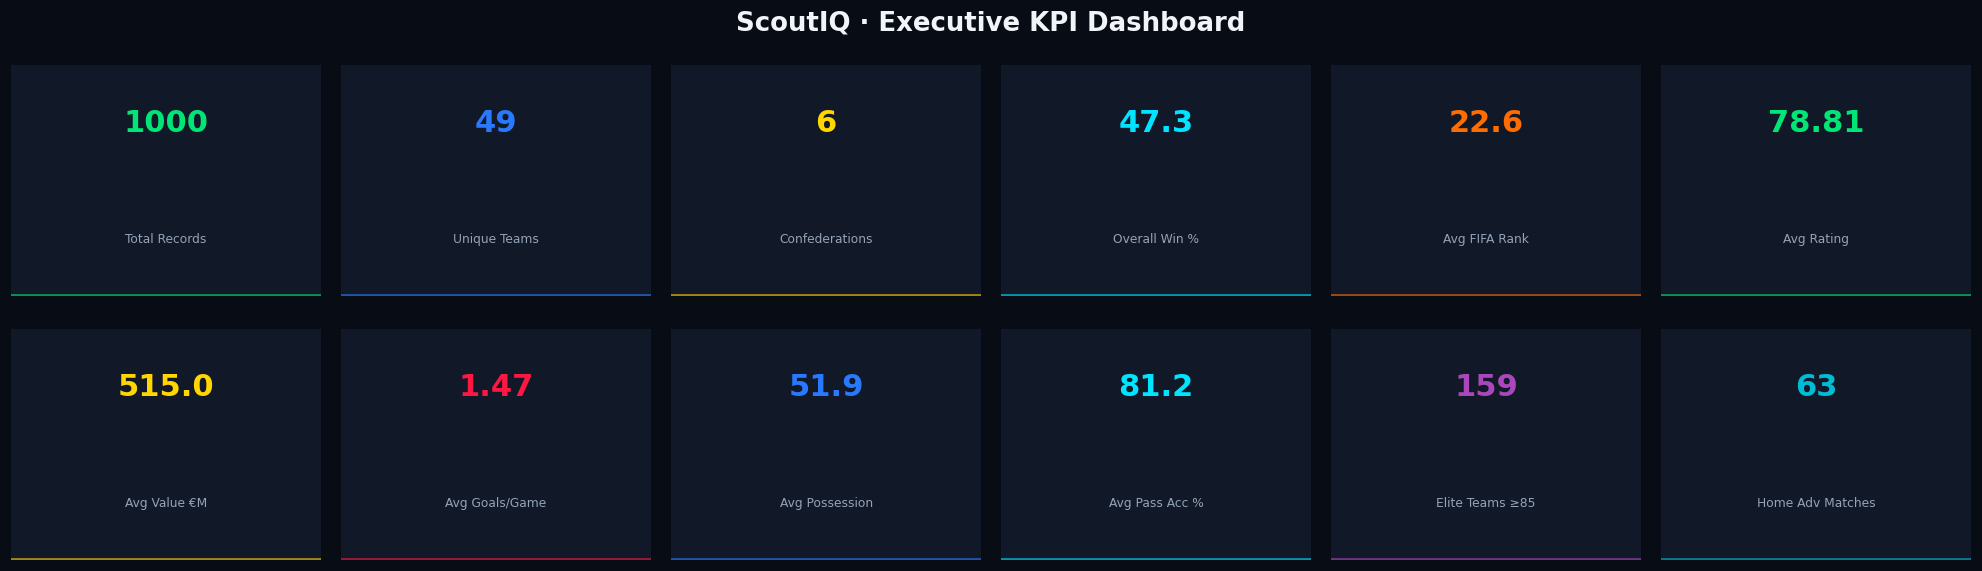

Statistical context:
  Win rate median by confederation:
    AFC           35.5%  (n=107)
    CAF           32.9%  (n=143)
    CONCACAF      43.1%  (n=109)
    CONMEBOL      55.0%  (n=180)
    OFC           17.6%  (n=17)
    UEFA          53.8%  (n=444)


In [2]:
# ── Full KPI Board ────────────────────────────────────────────────────────────
kpis = {
    'Total Records':     (len(train),                                       '📋', C_GREEN),
    'Unique Teams':      (train['team_name'].nunique(),                     '🌍', C_BLUE),
    'Confederations':    (train['confederation'].nunique(),                  '🏟️', C_GOLD),
    'Overall Win %':     (round(train['winner'].mean()*100, 1),             '🎯', C_CYAN),
    'Avg FIFA Rank':     (round(train['fifa_rank'].mean(), 1),              '🏆', C_ORANGE),
    'Avg Rating':        (round(train['avg_player_rating'].mean(), 2),      '⭐', C_GREEN),
    'Avg Value €M':      (round(train['market_value_million_eur'].mean(),0),'💰', C_GOLD),
    'Avg Goals/Game':    (round(train['goals_scored_avg'].mean(), 2),       '⚽', C_RED),
    'Avg Possession':    (round(train['possession_avg'].mean(), 1),         '🔄', C_BLUE),
    'Avg Pass Acc %':    (round(train['passing_accuracy'].mean(), 1),       '📐', C_CYAN),
    'Elite Teams ≥85':   (int((train['avg_player_rating']>=85).sum()),      '🌟', C_PURPLE),
    'Home Adv Matches':  (int(train['host_advantage'].sum()),               '🏠', C_TEAL),
}

fig = plt.figure(figsize=(18, 5))
fig.patch.set_facecolor(DARK)
cols = 6
for idx, (label, (value, icon, color)) in enumerate(kpis.items()):
    row, col = divmod(idx, cols)
    ax = fig.add_axes([col/cols + 0.005, 1 - (row+1)*0.48, 1/cols - 0.01, 0.42])
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_edgecolor(color + '55')
        spine.set_linewidth(1.8)
    ax.axhline(y=0, color=color, linewidth=2.5, xmin=0, xmax=1, alpha=0.6)
    ax.text(0.5, 0.75, str(value), ha='center', va='center',
            fontsize=20, fontweight='black', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=8, color=SUB, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.grid(False)

fig.suptitle('ScoutIQ · Executive KPI Dashboard', fontsize=17,
             fontweight='black', color=TXT, y=1.04)
plt.show()

# Statistical context
print('Statistical context:')
print(f'  Win rate median by confederation:')
for c, g in train.groupby('confederation'):
    print(f'    {c:<12} {g["winner"].mean()*100:5.1f}%  (n={len(g)})')


## 2 · Distribution Analysis + Normality Tests


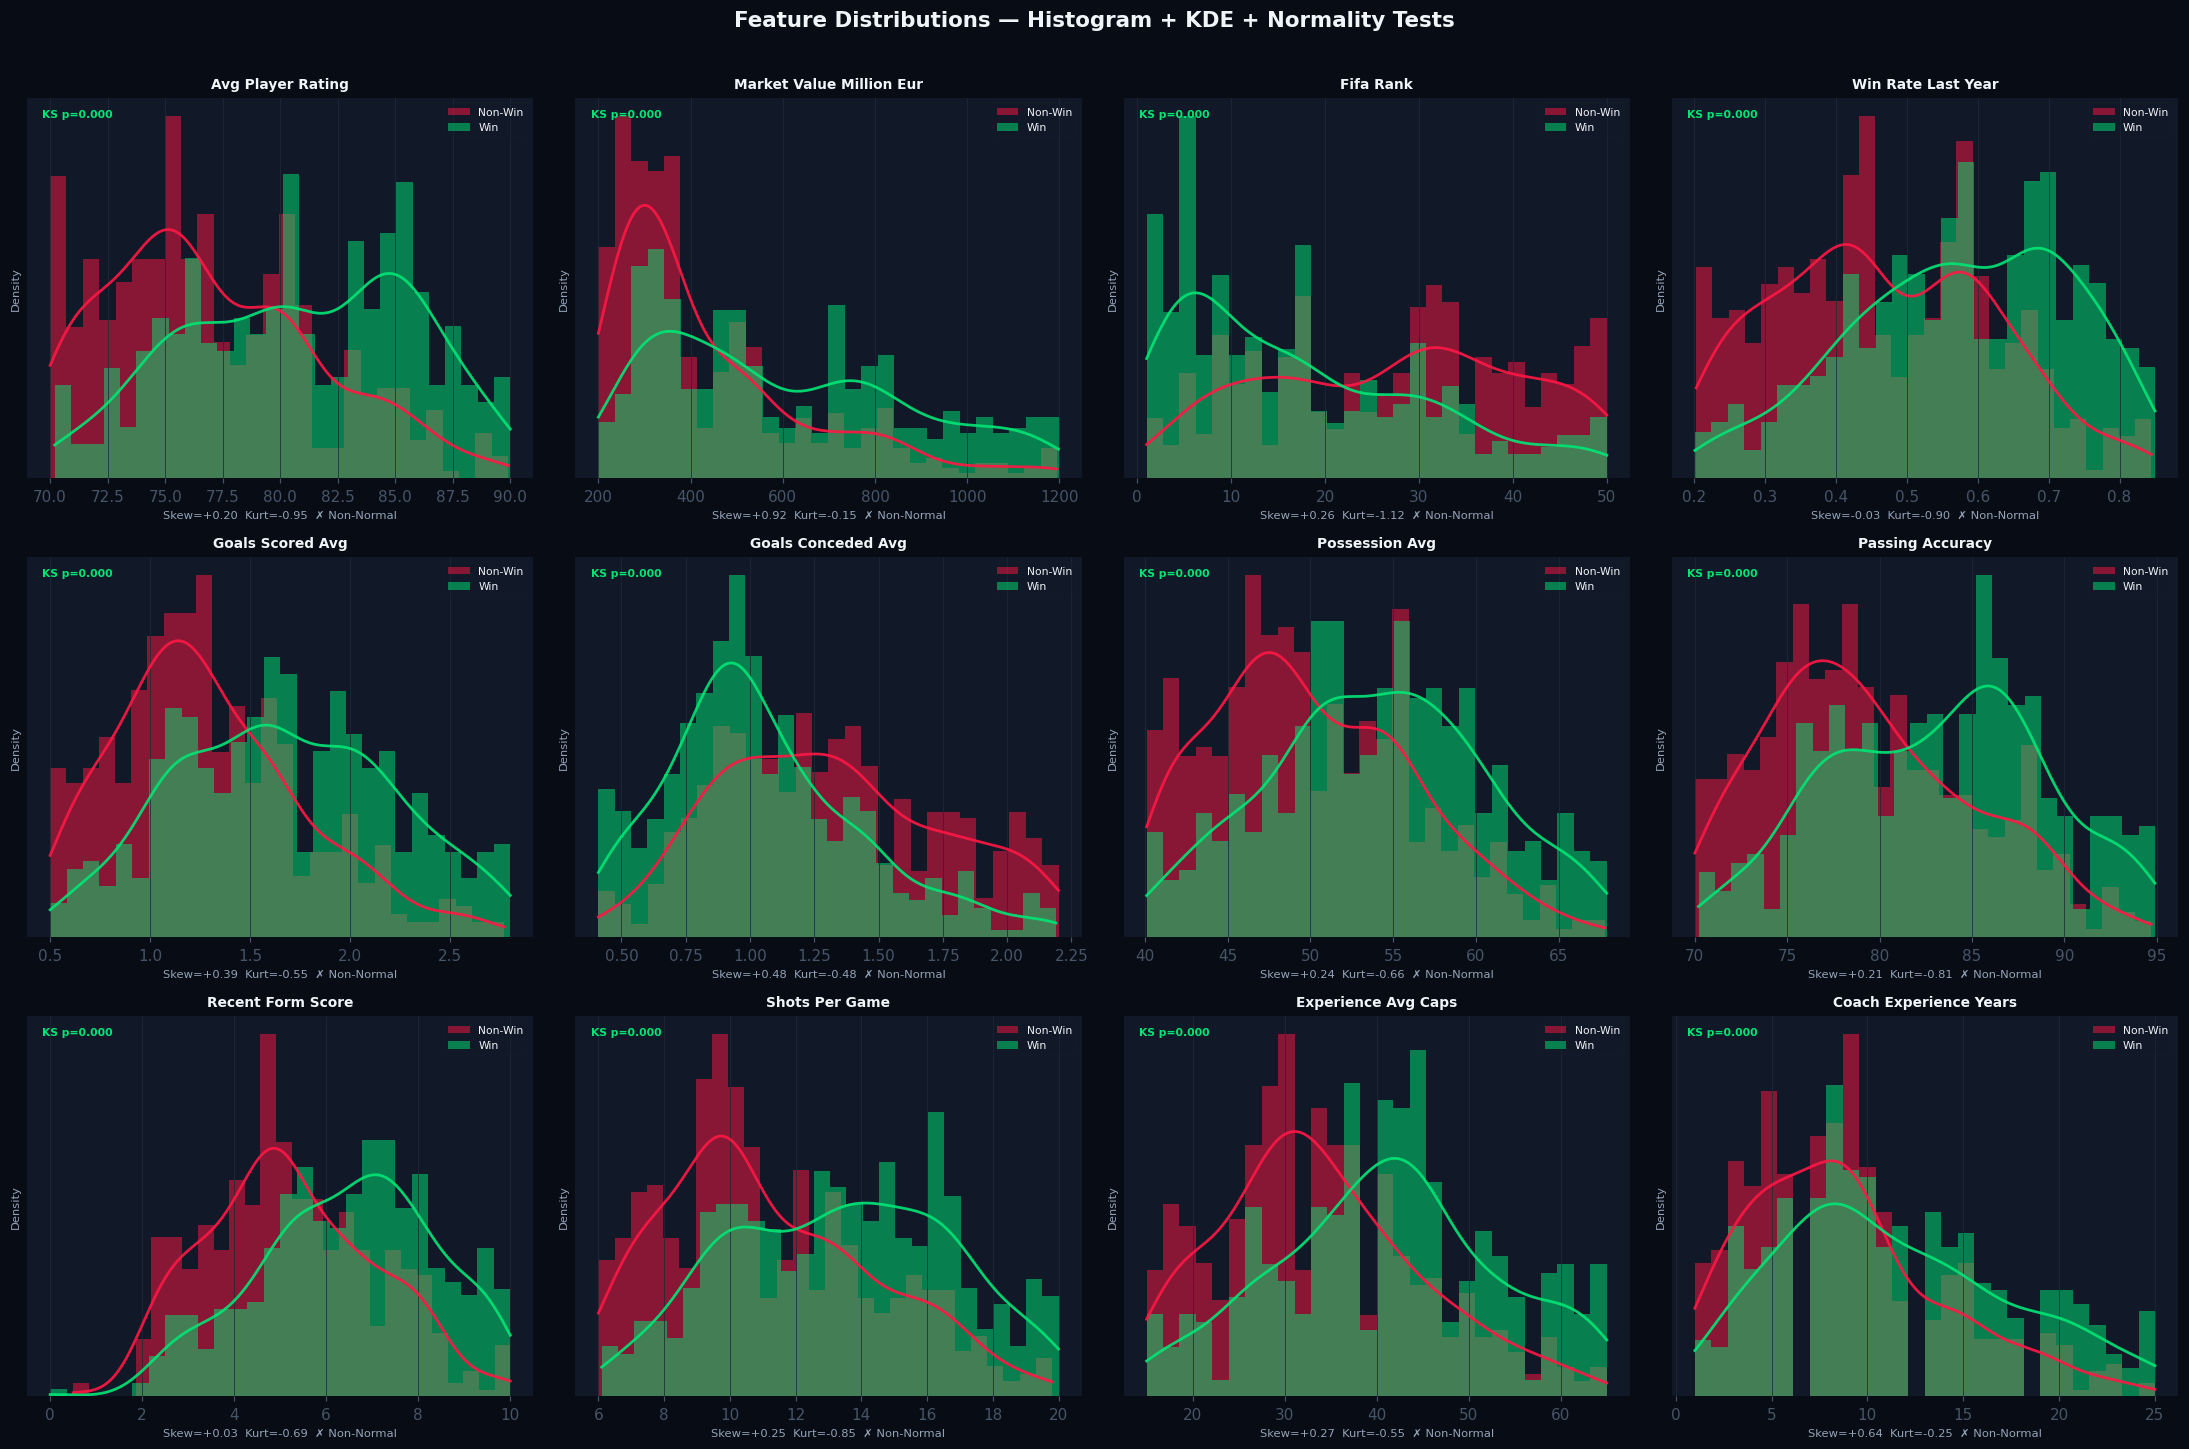

KS p < 0.05 → feature significantly separates Win vs Non-Win distributions.


In [3]:
# ── Distribution Grid with Skew/Kurt/Normality ───────────────────────────────
plot_cols = [
    'avg_player_rating', 'market_value_million_eur', 'fifa_rank',
    'win_rate_last_year', 'goals_scored_avg', 'goals_conceded_avg',
    'possession_avg', 'passing_accuracy', 'recent_form_score',
    'shots_per_game', 'experience_avg_caps', 'coach_experience_years',
]

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle('Feature Distributions — Histogram + KDE + Normality Tests',
             fontsize=14, fontweight='bold', y=1.01, color=TXT)

for ax, col in zip(axes.flat, plot_cols):
    data = train[col].dropna()
    w0   = train[train['winner']==0][col].dropna()
    w1   = train[train['winner']==1][col].dropna()

    # Stacked histograms
    ax.hist(w0, bins=28, density=True, alpha=0.5, color=C_RED,   label='Non-Win', edgecolor='none')
    ax.hist(w1, bins=28, density=True, alpha=0.5, color=C_GREEN, label='Win',     edgecolor='none')

    # KDE overlay
    from scipy.stats import gaussian_kde
    for d, c in [(w0, C_RED), (w1, C_GREEN)]:
        if len(d) > 5:
            kde = gaussian_kde(d, bw_method=0.3)
            xs  = np.linspace(d.min(), d.max(), 200)
            ax.plot(xs, kde(xs), color=c, linewidth=1.8, alpha=0.9)

    # Stats annotations
    sk  = skew(data)
    kt  = kurtosis(data)
    _, p_norm = normaltest(data)
    _, p_ks   = ks_2samp(w0, w1)
    normal_flag = '✓ Normal' if p_norm > 0.05 else '✗ Non-Normal'

    ax.set_title(col.replace('_',' ').title(), fontsize=9, fontweight='bold')
    ax.set_xlabel(f'Skew={sk:+.2f}  Kurt={kt:.2f}  {normal_flag}', fontsize=7.5, color=SUB)
    ax.set_ylabel('Density', fontsize=7.5)
    ax.legend(fontsize=7, loc='upper right')

    # KS result badge
    ks_color = C_GREEN if p_ks < 0.05 else MUTED
    ax.text(0.03, 0.97, f'KS p={p_ks:.3f}', transform=ax.transAxes,
            fontsize=7, color=ks_color, va='top', fontweight='bold')
    ax.set_yticks([])

plt.tight_layout()
plt.show()
print('KS p < 0.05 → feature significantly separates Win vs Non-Win distributions.')


## 3 · Full Correlation Analysis


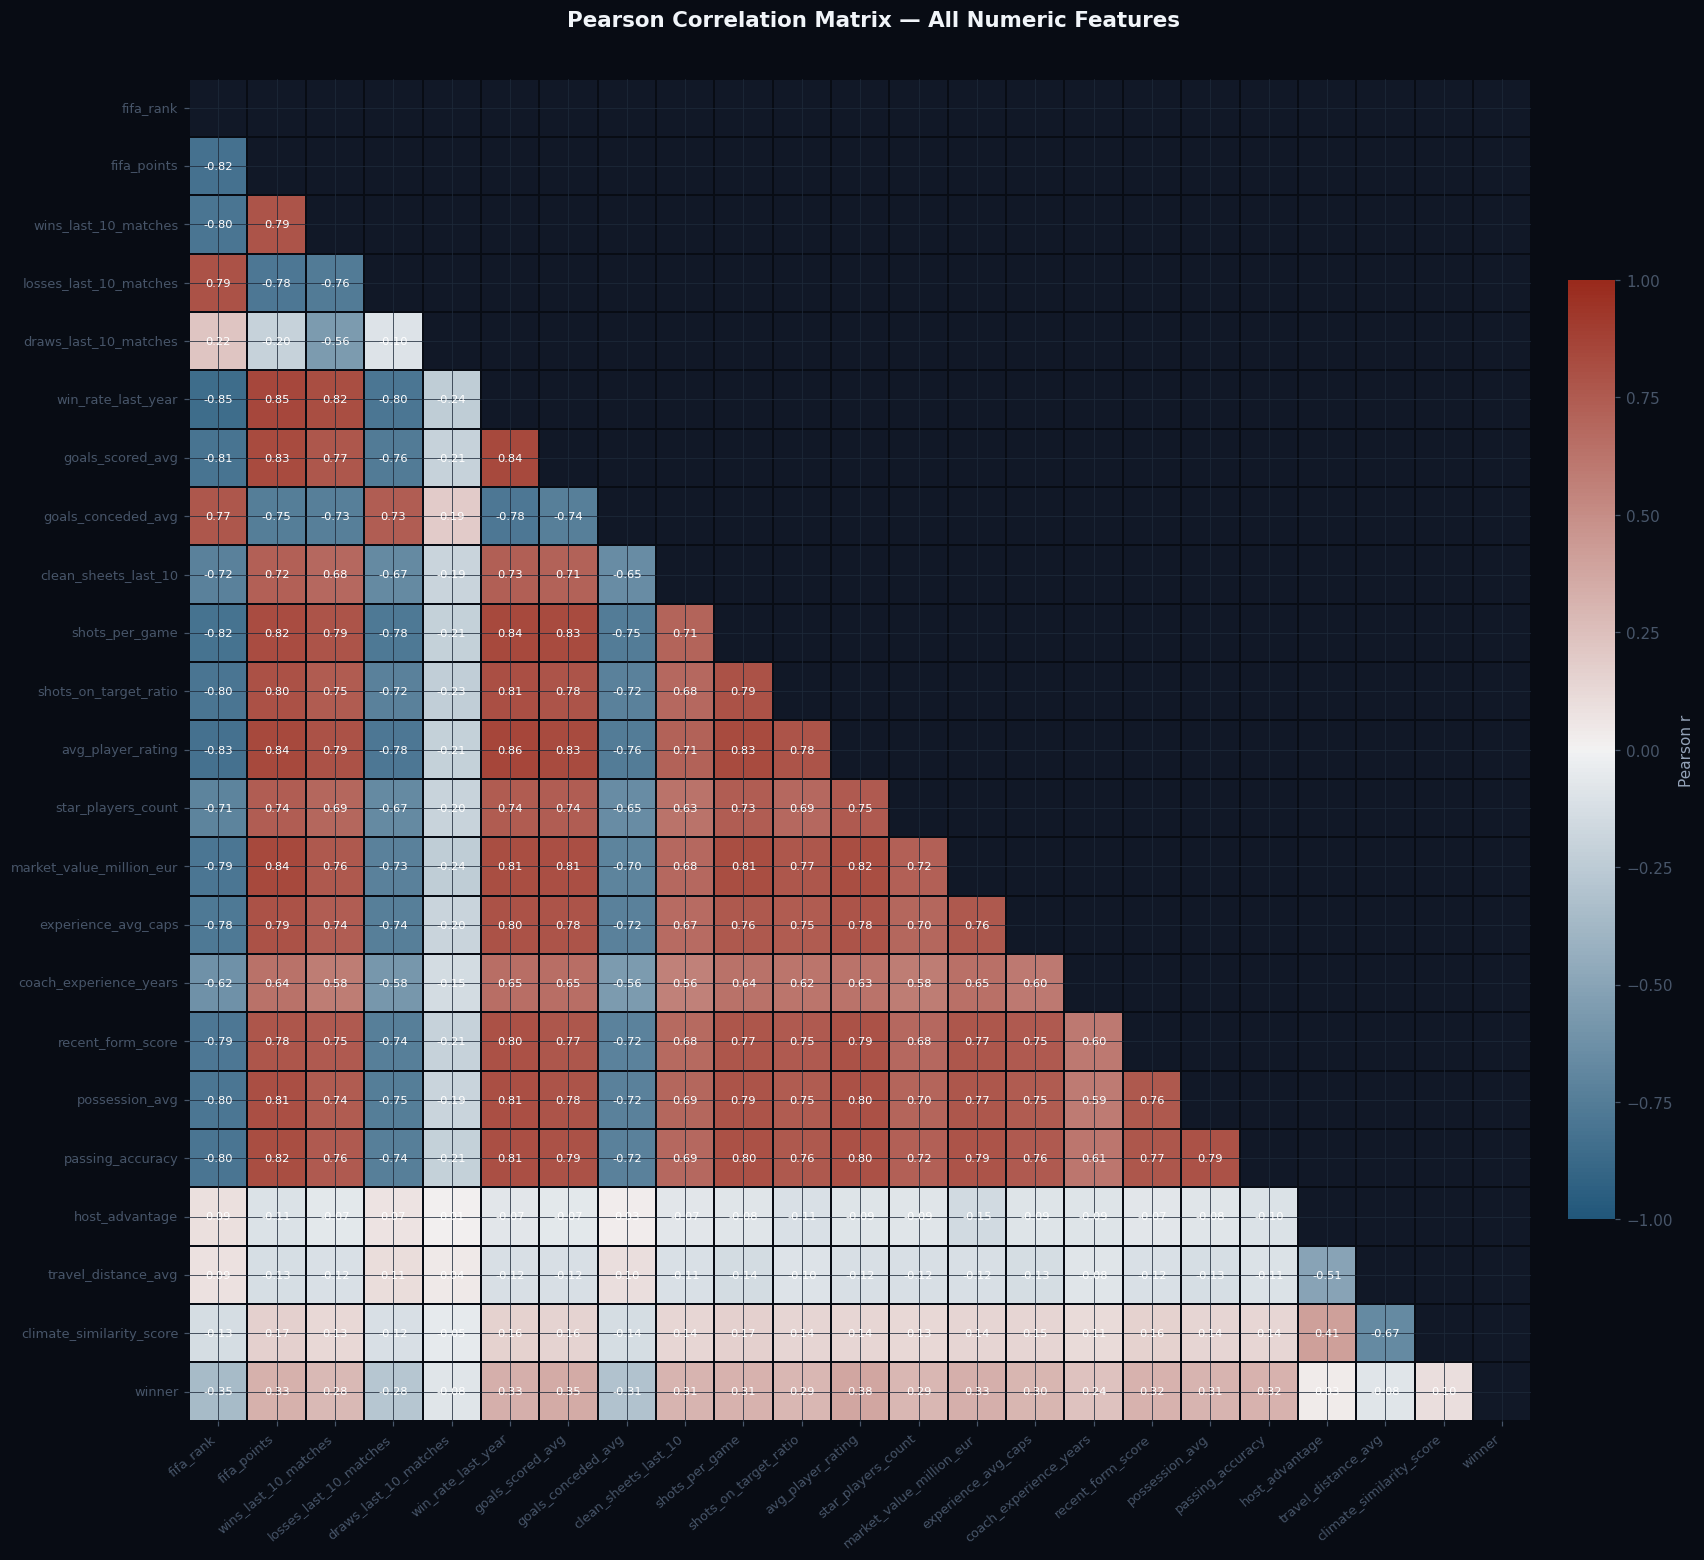

In [4]:
# ── Pearson Correlation Heatmap ───────────────────────────────────────────────
corr = train[NUM_COLS + ['winner']].corr()

fig, ax = plt.subplots(figsize=(18, 14))
fig.suptitle('Pearson Correlation Matrix — All Numeric Features',
             fontsize=14, fontweight='bold', color=TXT, y=1.01)

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(240, 15, s=85, l=35, as_cmap=True)

sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7.5, 'color': 'white'},
    square=True, linewidths=0.3, linecolor=DARK,
    ax=ax, vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r', 'pad': 0.02}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)
plt.tight_layout()
plt.show()


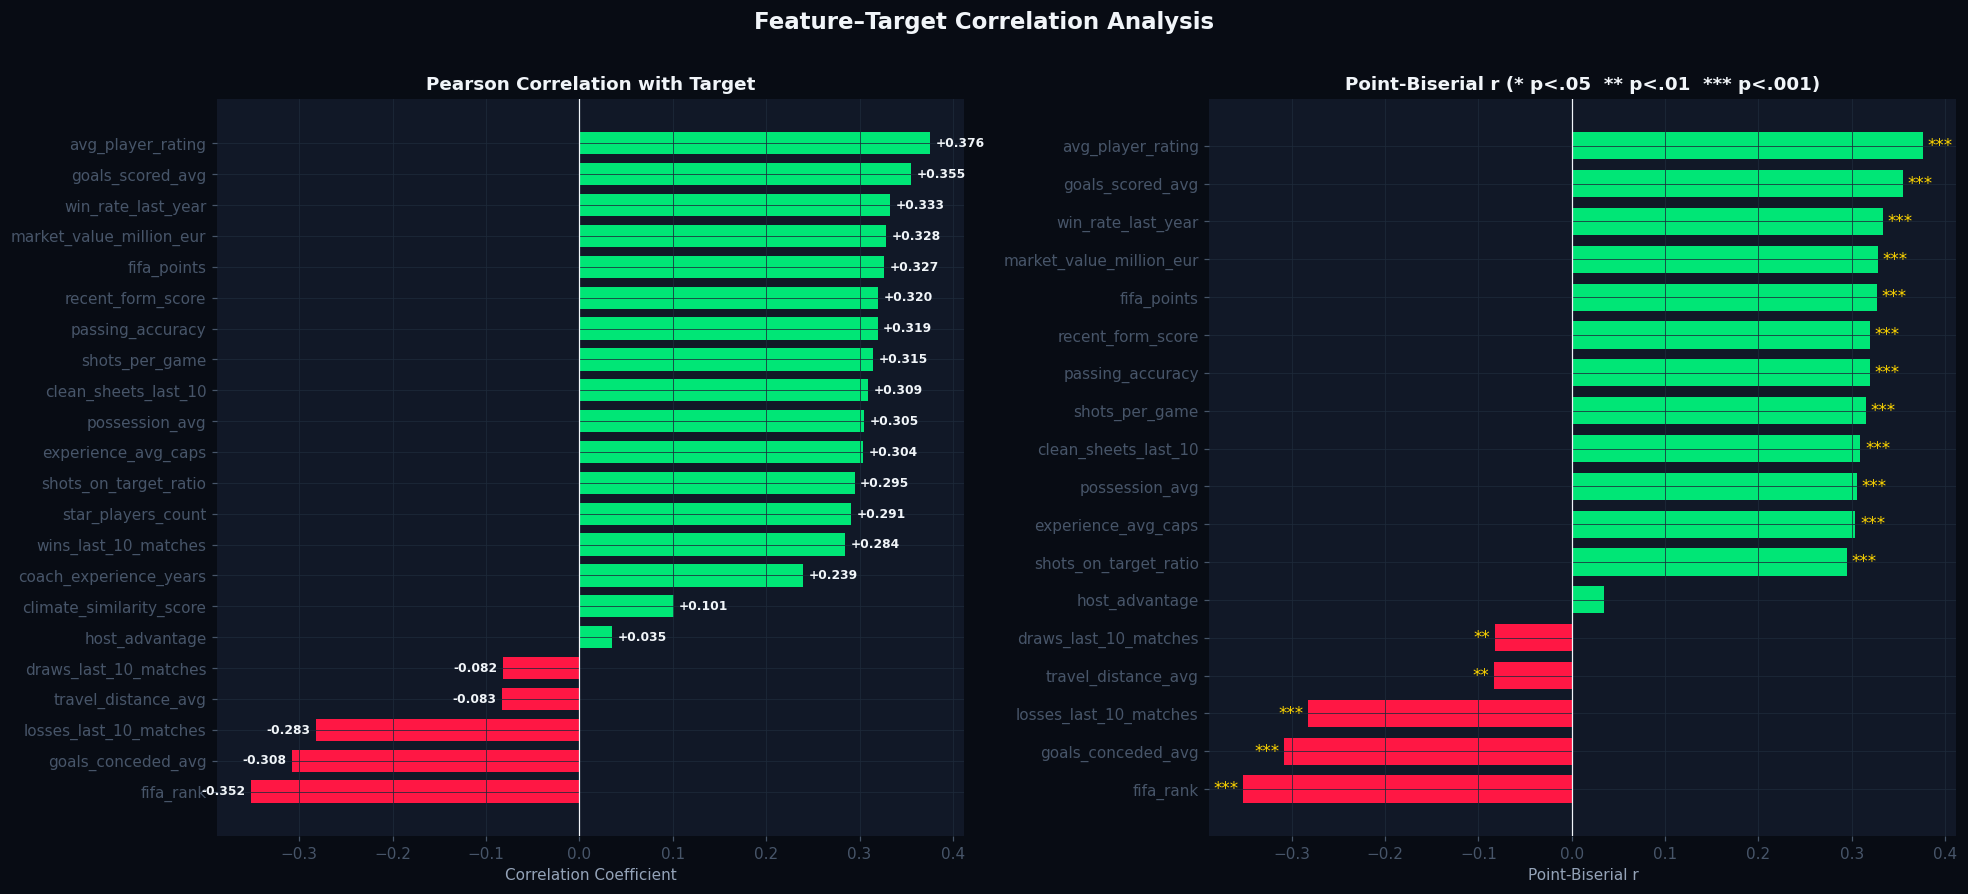

Top 5 WIN predictors:
                               r    p
avg_player_rating         0.3757  0.0
goals_scored_avg          0.3550  0.0
win_rate_last_year        0.3331  0.0
market_value_million_eur  0.3283  0.0
fifa_points               0.3267  0.0

Top 5 LOSS predictors:
                             r       p
draws_last_10_matches  -0.0820  0.0095
travel_distance_avg    -0.0834  0.0083
losses_last_10_matches -0.2826  0.0000
goals_conceded_avg     -0.3081  0.0000
fifa_rank              -0.3517  0.0000


In [5]:
# ── Correlation with Target — Ranked ──────────────────────────────────────────
corr_target = train[NUM_COLS].corrwith(train['winner']).sort_values(ascending=False)

# Point-biserial for binary target
pb_results = {}
for col in NUM_COLS:
    r, p = pointbiserialr(train['winner'], train[col])
    pb_results[col] = {'r': round(r, 4), 'p': round(p, 4)}

pb_df = pd.DataFrame(pb_results).T.sort_values('r', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left — all features sorted
colors_all = [C_GREEN if v > 0 else C_RED for v in corr_target.values]
axes[0].barh(corr_target.index[::-1], corr_target.values[::-1],
             color=colors_all[::-1], edgecolor='none', height=0.72)
axes[0].axvline(0, color=TXT, linewidth=0.8)
for i, (val, feat) in enumerate(zip(corr_target.values[::-1], corr_target.index[::-1])):
    xpos = val + 0.006 if val >= 0 else val - 0.006
    axes[0].text(xpos, i, f'{val:+.3f}', va='center',
                 ha='left' if val >= 0 else 'right',
                 fontsize=8, color=TXT, fontweight='bold')
axes[0].set_title('Pearson Correlation with Target', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Correlation Coefficient')

# Right — point-biserial with significance bands
top_pb = pb_df.head(12)
bot_pb = pb_df.tail(6)
show_pb = pd.concat([top_pb, bot_pb])
bar_c = [C_GREEN if r > 0 else C_RED for r in show_pb['r']]
axes[1].barh(show_pb.index[::-1], show_pb['r'][::-1],
             color=bar_c[::-1], edgecolor='none', height=0.72)
axes[1].axvline(0, color=TXT, linewidth=0.8)
for feat, row in show_pb.iterrows():
    sig = '***' if row['p'] < 0.001 else '**' if row['p'] < 0.01 else '*' if row['p'] < 0.05 else ''
    idx = list(show_pb.index[::-1]).index(feat)
    xpos = row['r'] + 0.005 if row['r'] >= 0 else row['r'] - 0.005
    axes[1].text(xpos, idx, f'{sig}', va='center',
                 ha='left' if row['r'] >= 0 else 'right', color=C_GOLD, fontsize=11)
axes[1].set_title('Point-Biserial r (* p<.05  ** p<.01  *** p<.001)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Point-Biserial r')

plt.suptitle('Feature–Target Correlation Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Top 5 WIN predictors:')
print(pb_df.head(5).to_string())
print()
print('Top 5 LOSS predictors:')
print(pb_df.tail(5).to_string())


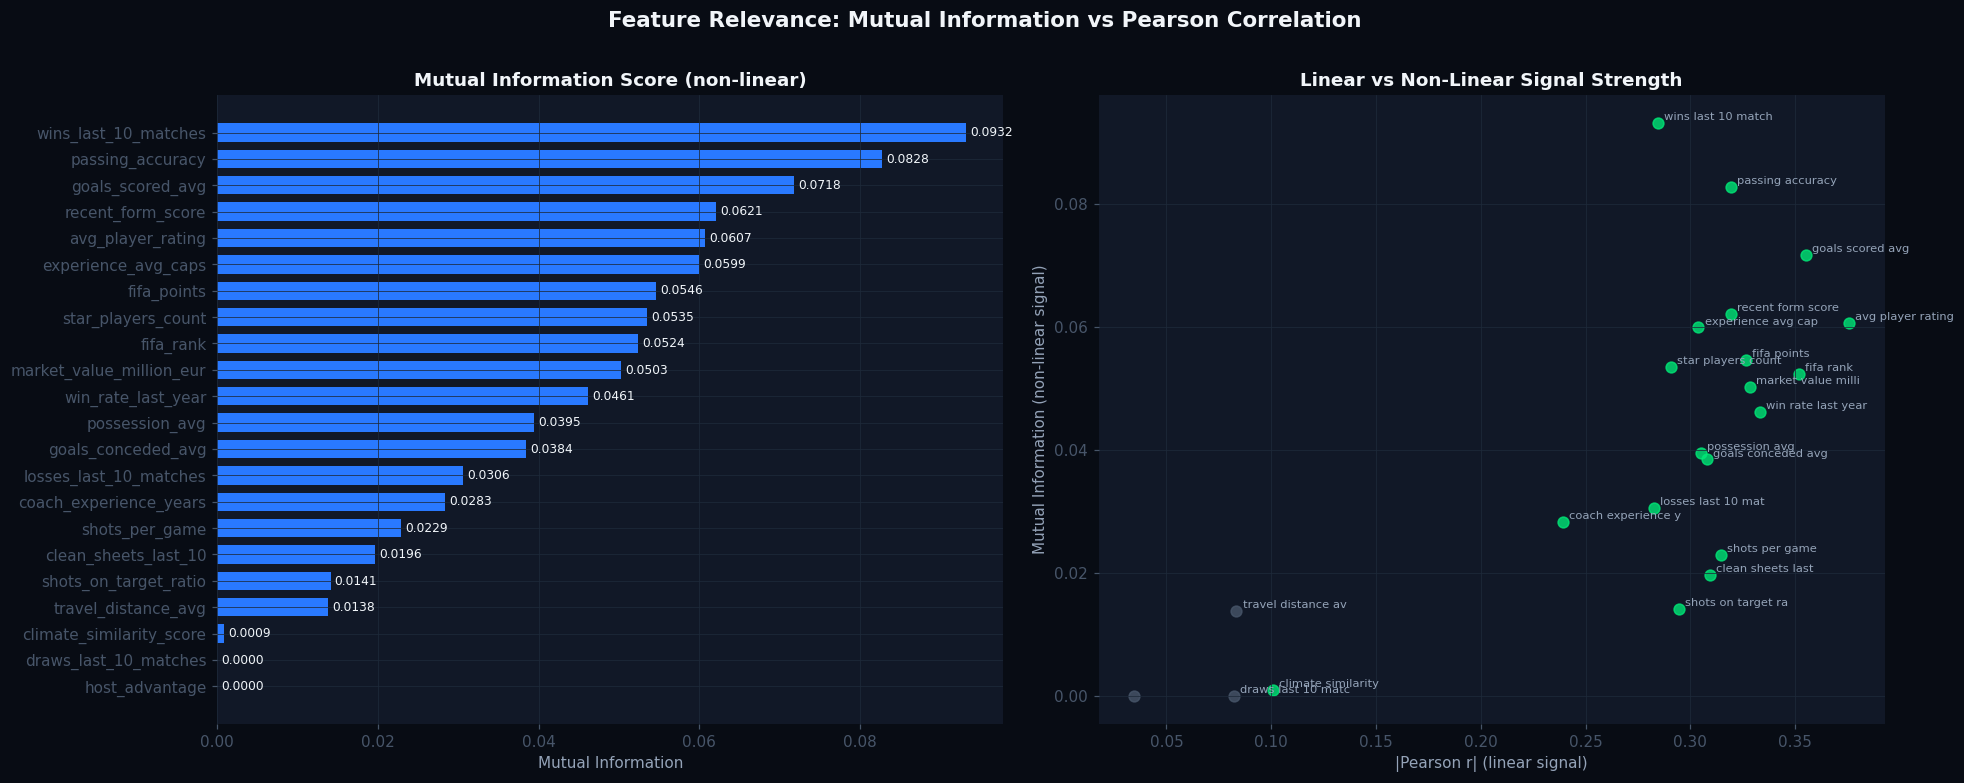

MI > Pearson → feature has non-linear relationship with outcome

                 feature       MI
    wins_last_10_matches 0.093175
        passing_accuracy 0.082780
        goals_scored_avg 0.071784
       recent_form_score 0.062095
       avg_player_rating 0.060694
     experience_avg_caps 0.059944
             fifa_points 0.054591
      star_players_count 0.053510
               fifa_rank 0.052417
market_value_million_eur 0.050260
      win_rate_last_year 0.046141
          possession_avg 0.039459
      goals_conceded_avg 0.038444
  losses_last_10_matches 0.030573
  coach_experience_years 0.028332
          shots_per_game 0.022919
    clean_sheets_last_10 0.019611
   shots_on_target_ratio 0.014124
     travel_distance_avg 0.013823
climate_similarity_score 0.000865
   draws_last_10_matches 0.000000
          host_advantage 0.000000


In [6]:
# ── Mutual Information (non-linear signal) ────────────────────────────────────
X_mi = train[NUM_COLS].fillna(train[NUM_COLS].median())
y_mi = train['winner'].values

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=42)
mi_df = pd.DataFrame({'feature': NUM_COLS, 'MI': mi_scores})          .sort_values('MI', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# MI vs Pearson side-by-side
axes[0].barh(mi_df['feature'][::-1], mi_df['MI'][::-1],
             color=[C_BLUE]*len(mi_df), edgecolor='none', height=0.7)
for i, (feat, mi) in enumerate(zip(mi_df['feature'][::-1], mi_df['MI'][::-1])):
    axes[0].text(mi + 0.0005, i, f'{mi:.4f}', va='center', fontsize=8, color=TXT)
axes[0].set_title('Mutual Information Score (non-linear)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Mutual Information')

# Scatter: Pearson vs MI  
for feat in mi_df['feature']:
    pearson_r = abs(corr_target[feat])
    mi_val    = mi_df.set_index('feature').loc[feat, 'MI']
    color     = CONF_COLORS.get('UEFA', C_BLUE)
    axes[1].scatter(pearson_r, mi_val, s=50, alpha=0.8,
                    color=C_GREEN if pearson_r > 0.1 else MUTED)
    if pearson_r > 0.08 or mi_val > 0.02:
        axes[1].annotate(feat.replace('_', ' ')[:18], (pearson_r, mi_val),
                         fontsize=7.5, color=SUB, xytext=(4, 2),
                         textcoords='offset points')

axes[1].set_xlabel('|Pearson r| (linear signal)', fontsize=10)
axes[1].set_ylabel('Mutual Information (non-linear signal)', fontsize=10)
axes[1].set_title('Linear vs Non-Linear Signal Strength', fontweight='bold', fontsize=12)

plt.suptitle('Feature Relevance: Mutual Information vs Pearson Correlation',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('MI > Pearson → feature has non-linear relationship with outcome')
print()
print(mi_df.to_string(index=False))


## 4 · Confederation Deep-Dive


In [7]:
# ── Confederation Multi-Metric Benchmark ─────────────────────────────────────
conf_metrics = [
    'win_rate_last_year', 'avg_player_rating', 'market_value_million_eur',
    'goals_scored_avg', 'goals_conceded_avg', 'possession_avg',
    'passing_accuracy', 'recent_form_score', 'fifa_rank',
    'shots_per_game', 'clean_sheets_last_10', 'star_players_count',
]

conf_agg = train.groupby('confederation')[conf_metrics + ['winner']].agg([
    'mean', 'std', 'median'
]).round(3)
conf_agg.columns = ['_'.join(c) for c in conf_agg.columns]

conf_mean = train.groupby('confederation')[conf_metrics].mean().round(3)
conf_wr   = (train.groupby('confederation')['winner'].mean() * 100).round(1)
conf_count= train.groupby('confederation').size()

print('Confederation Intelligence Report:')
display_df = conf_mean.copy()
display_df.insert(0, 'win_rate_%', conf_wr)
display_df.insert(0, 'n_matches', conf_count)
print(display_df.to_string())


Confederation Intelligence Report:
               n_matches  win_rate_%  win_rate_last_year  avg_player_rating  market_value_million_eur  goals_scored_avg  goals_conceded_avg  possession_avg  passing_accuracy  recent_form_score  fifa_rank  shots_per_game  clean_sheets_last_10  star_players_count
confederation                                                                                                                                                                                                                                                        
AFC                  107        35.5               0.416             75.657                   337.140             1.132               1.402          48.149            77.539              4.776     30.346           9.968                 1.794               1.383
CAF                  143        32.9               0.390             74.673                   323.469             1.064               1.521          46.720            76.423      

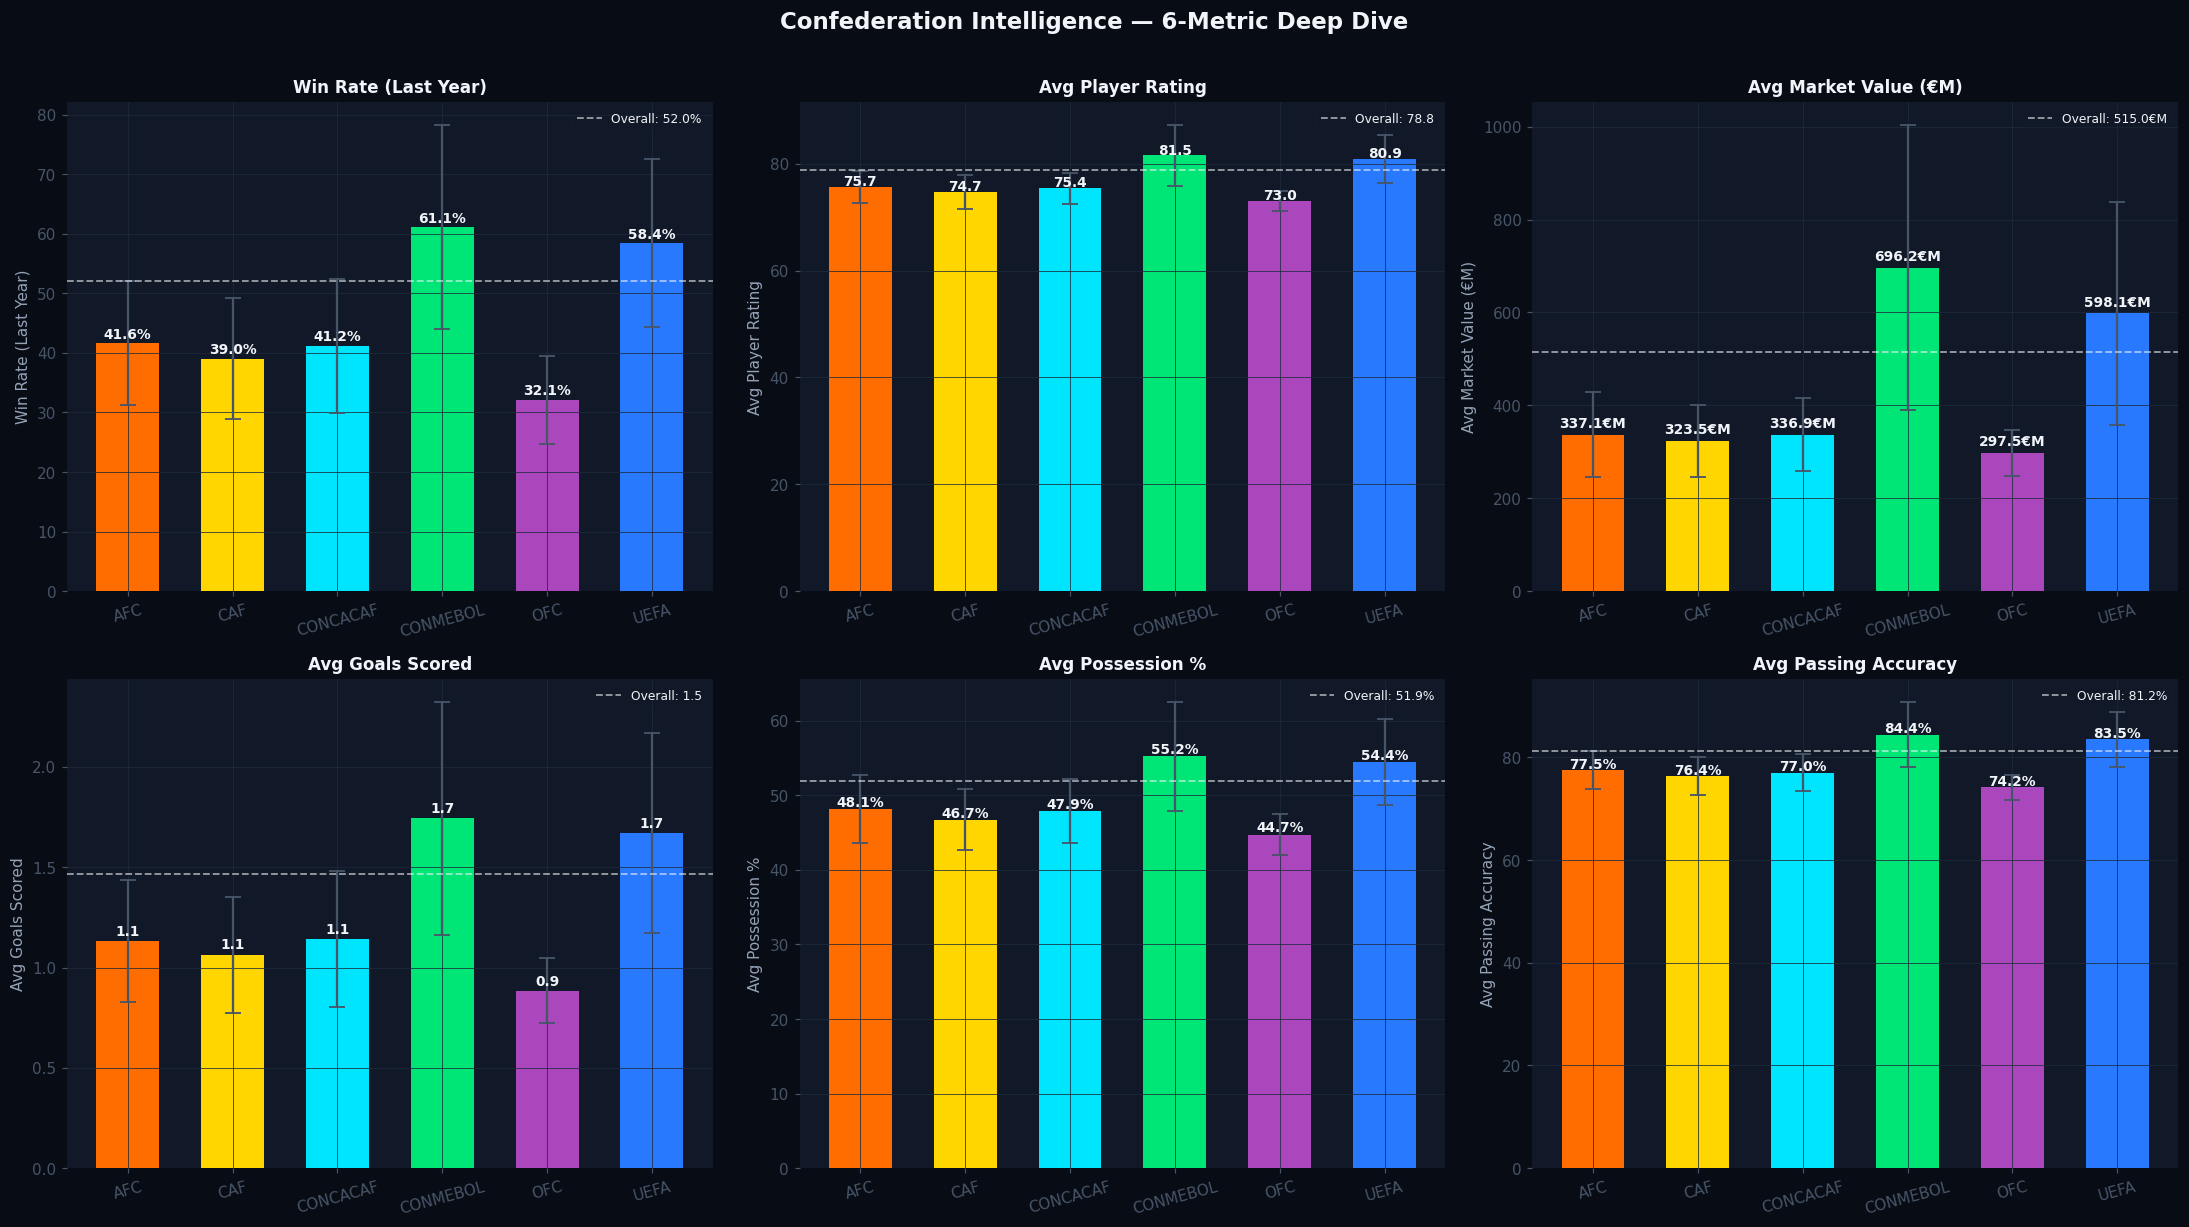

In [8]:
# ── 6-Panel Confederation Dashboard ──────────────────────────────────────────
metrics_4 = [
    ('win_rate_last_year', 'Win Rate (Last Year)', '%', 100),
    ('avg_player_rating',  'Avg Player Rating',     '',   1),
    ('market_value_million_eur', 'Avg Market Value (€M)', '€M', 1),
    ('goals_scored_avg',   'Avg Goals Scored',      '',   1),
    ('possession_avg',     'Avg Possession %',      '%',  1),
    ('passing_accuracy',   'Avg Passing Accuracy',  '%',  1),
]

confs  = conf_mean.index.tolist()
colors = [CONF_COLORS.get(c, MUTED) for c in confs]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Confederation Intelligence — 6-Metric Deep Dive',
             fontsize=15, fontweight='bold', y=1.01, color=TXT)

for ax, (metric, label, unit, mult) in zip(axes.flat, metrics_4):
    vals    = conf_mean[metric] * mult
    std_vals = train.groupby('confederation')[metric].std() * mult
    bar_c   = [CONF_COLORS.get(c, MUTED) for c in confs]
    bars    = ax.bar(confs, vals, color=bar_c, edgecolor='none', width=0.6,
                     yerr=std_vals, error_kw=dict(ecolor=MUTED, capsize=5, capthick=1.2))
    overall = train[metric].mean() * mult
    ax.axhline(overall, color=TXT, linewidth=1.2, linestyle='--', alpha=0.6,
               label=f'Overall: {overall:.1f}{unit}')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+std_vals.max()*0.05,
                f'{val:.1f}{unit}', ha='center', fontsize=9, fontweight='bold', color=TXT)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


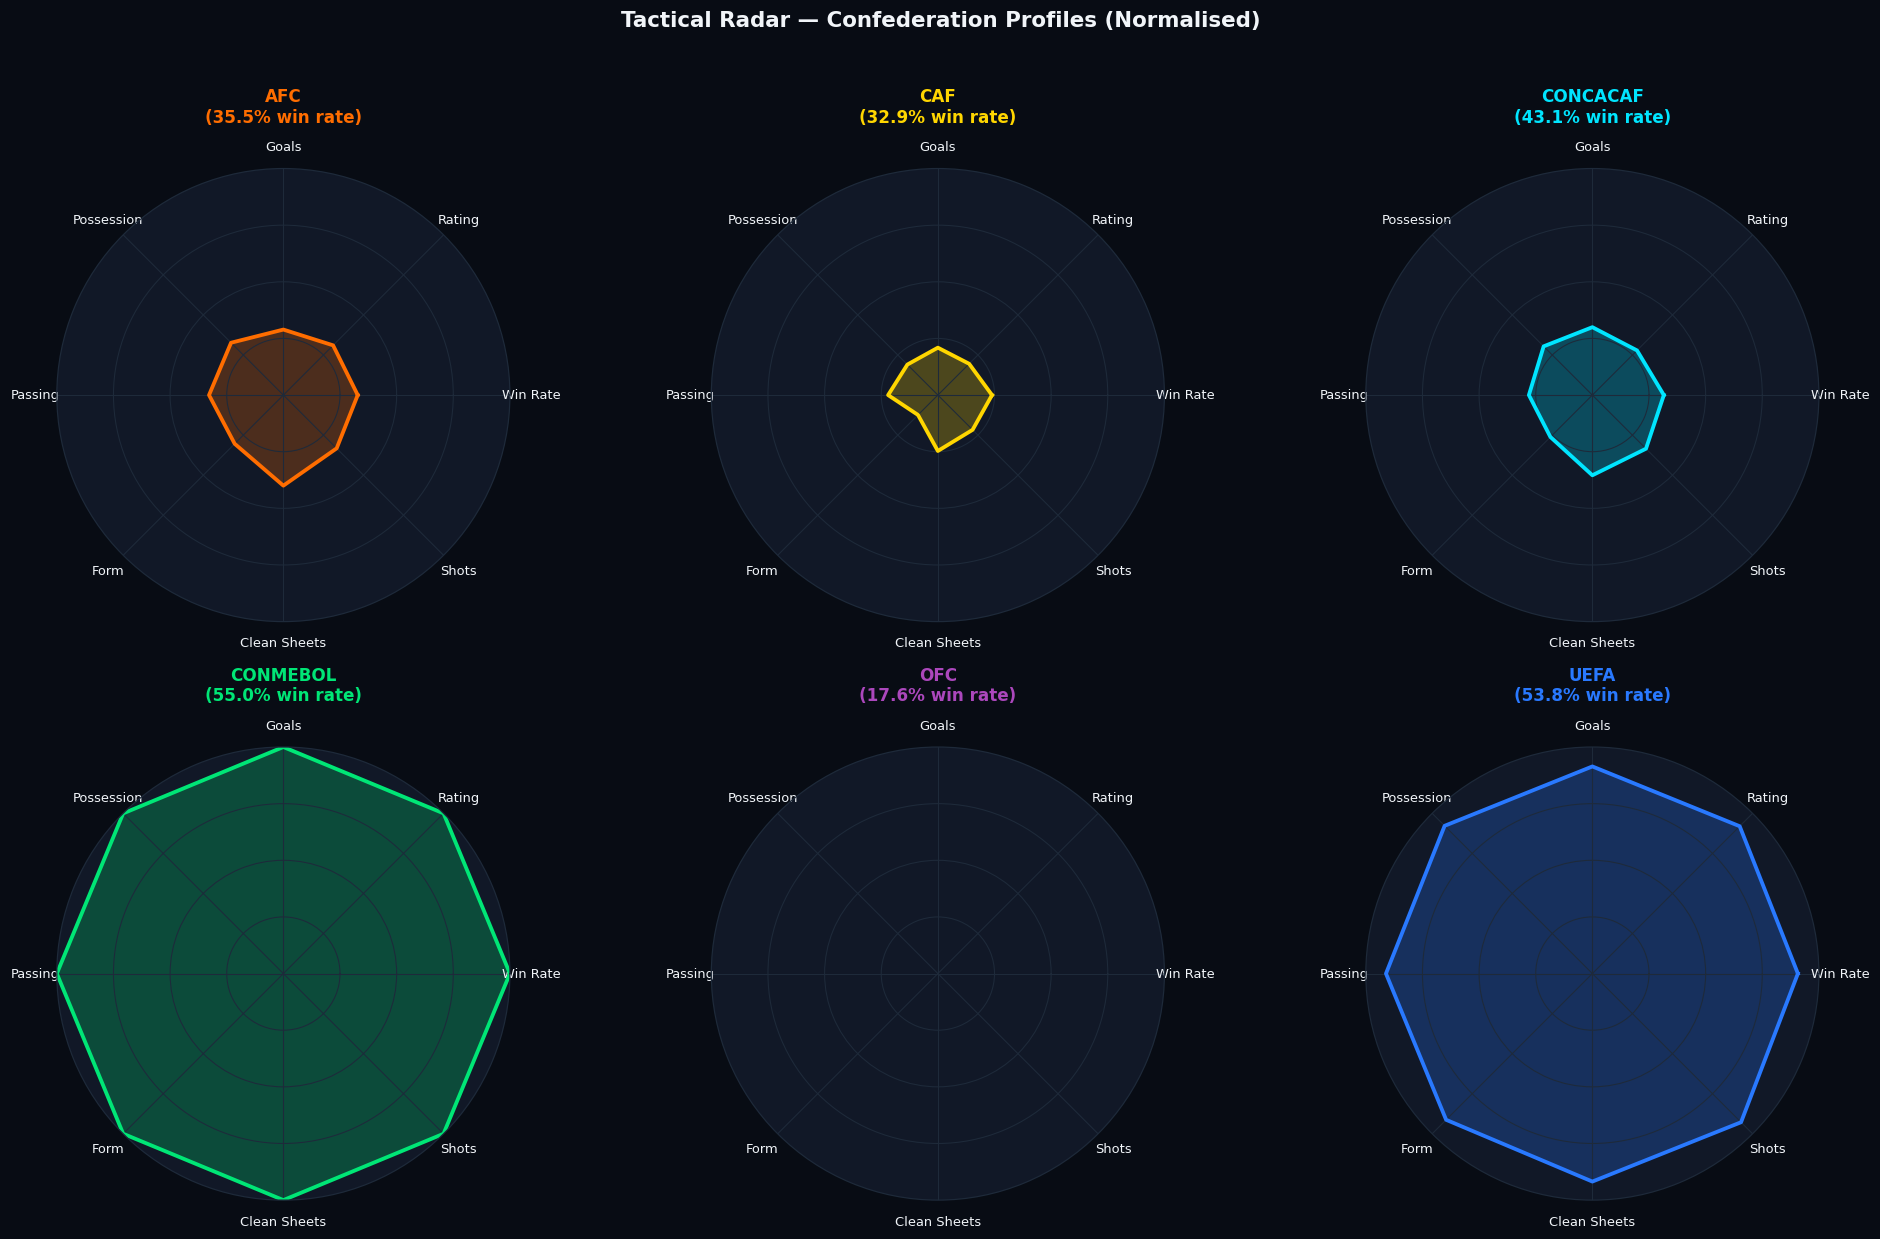

In [9]:
# ── Radar Chart — Confederation Tactical Profiles ────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib

# Normalise metrics for radar (0-1 scale)
radar_metrics = ['win_rate_last_year','avg_player_rating','goals_scored_avg',
                 'possession_avg','passing_accuracy','recent_form_score',
                 'clean_sheets_last_10','shots_per_game']
radar_labels  = ['Win Rate','Rating','Goals','Possession','Passing','Form','Clean Sheets','Shots']

conf_radar = train.groupby('confederation')[radar_metrics].mean()
conf_radar_norm = (conf_radar - conf_radar.min()) / (conf_radar.max() - conf_radar.min() + 1e-9)

N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the ring

fig, axes = plt.subplots(2, 3, figsize=(18, 11),
                          subplot_kw=dict(projection='polar'))
fig.suptitle('Tactical Radar — Confederation Profiles (Normalised)',
             fontsize=14, fontweight='bold', y=1.02, color=TXT)
fig.patch.set_facecolor(DARK)

for ax, (conf, row) in zip(axes.flat, conf_radar_norm.iterrows()):
    vals  = row.tolist() + [row.iloc[0]]
    color = CONF_COLORS.get(conf, MUTED)
    ax.plot(angles, vals, color=color, linewidth=2.5, linestyle='-')
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8.5, color=TXT)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['', '', ''], fontsize=0)
    ax.grid(color=MID, linewidth=0.7)
    ax.spines['polar'].set_color(MID)
    ax.set_facecolor(CARD)
    wr = train[train['confederation']==conf]['winner'].mean()*100
    ax.set_title(conf + '\n(' + f'{wr:.1f}% win rate)', fontsize=11, fontweight='bold',
                 color=color, pad=12)

plt.tight_layout()
plt.show()


In [10]:
# ── ANOVA: Is confederation significant? ──────────────────────────────────────
from scipy.stats import f_oneway, kruskal

print('Statistical Tests: Does confederation significantly differ on key metrics?')
print('─' * 75)
print(f'{"Metric":<30} {"ANOVA F":>9} {"ANOVA p":>10} {"Kruskal H":>10} {"Kruskal p":>10} {"Sig"}')
print('─' * 75)

conf_groups = {c: g for c, g in train.groupby('confederation')}

for metric in ['avg_player_rating','market_value_million_eur','win_rate_last_year',
               'goals_scored_avg','possession_avg','passing_accuracy','fifa_rank']:
    groups = [g[metric].dropna().values for g in conf_groups.values()]
    F, p_f   = f_oneway(*groups)
    H, p_k   = kruskal(*groups)
    sig = '***' if p_f < 0.001 else '**' if p_f < 0.01 else '*' if p_f < 0.05 else 'ns'
    print(f'{metric:<30} {F:>9.2f} {p_f:>10.4f} {H:>10.2f} {p_k:>10.4f} {sig}')

print()
print('*** p<0.001 *** p<0.01 * p<0.05 ns=not significant')
print('Significant → confederation membership meaningfully predicts this metric')


Statistical Tests: Does confederation significantly differ on key metrics?
───────────────────────────────────────────────────────────────────────────
Metric                           ANOVA F    ANOVA p  Kruskal H  Kruskal p Sig
───────────────────────────────────────────────────────────────────────────
avg_player_rating                  94.16     0.0000     323.55     0.0000 ***
market_value_million_eur           97.02     0.0000     336.63     0.0000 ***
win_rate_last_year                 96.39     0.0000     342.40     0.0000 ***
goals_scored_avg                   81.76     0.0000     304.60     0.0000 ***
possession_avg                     81.66     0.0000     301.57     0.0000 ***
passing_accuracy                   94.51     0.0000     329.07     0.0000 ***
fifa_rank                         102.13     0.0000     345.49     0.0000 ***

*** p<0.001 *** p<0.01 * p<0.05 ns=not significant
Significant → confederation membership meaningfully predicts this metric


## 5 · Market Value & Transfer Intelligence


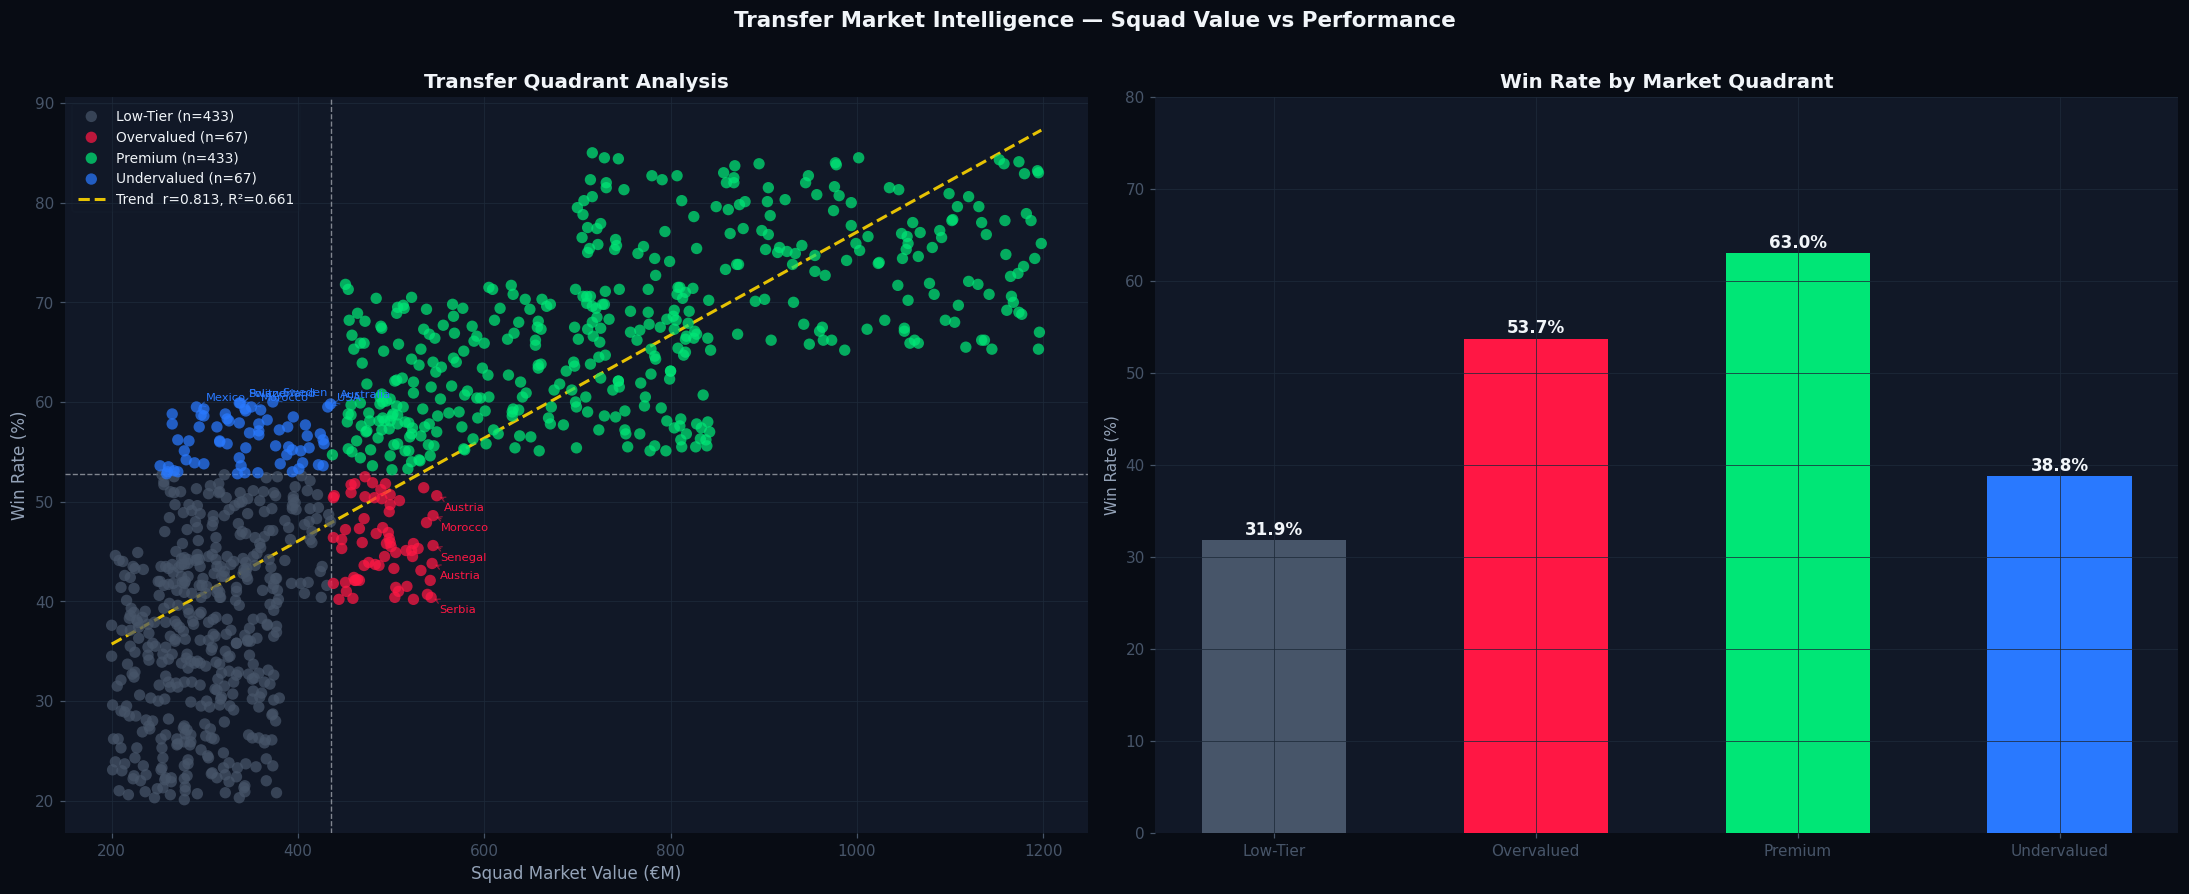

Quadrant counts:
  Low-Tier        n=433  win_rate=31.9%
  Premium         n=433  win_rate=63.0%
  Undervalued     n= 67  win_rate=38.8%
  Overvalued      n= 67  win_rate=53.7%


In [11]:
# ── Quadrant Analysis — Full Version ─────────────────────────────────────────
mv_med = train['market_value_million_eur'].median()
wr_med = train['win_rate_last_year'].median()

train['quadrant'] = 'Low-Tier'
train.loc[(train['market_value_million_eur'] >= mv_med) &
          (train['win_rate_last_year'] >= wr_med), 'quadrant'] = 'Premium'
train.loc[(train['market_value_million_eur'] <  mv_med) &
          (train['win_rate_last_year'] >= wr_med), 'quadrant'] = 'Undervalued'
train.loc[(train['market_value_million_eur'] >= mv_med) &
          (train['win_rate_last_year'] <  wr_med), 'quadrant'] = 'Overvalued'

qcolors = {'Premium':C_GREEN, 'Undervalued':C_BLUE, 'Overvalued':C_RED, 'Low-Tier':MUTED}
qcounts = train['quadrant'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Transfer Market Intelligence — Squad Value vs Performance',
             fontsize=14, fontweight='bold', y=1.01)

# Main scatter
for quad, g in train.groupby('quadrant'):
    axes[0].scatter(g['market_value_million_eur'], g['win_rate_last_year']*100,
                    color=qcolors[quad], alpha=0.72, s=55, label=f'{quad} (n={len(g)})',
                    edgecolors='none', zorder=3)

axes[0].axvline(mv_med, color=TXT, linewidth=0.9, linestyle='--', alpha=0.5)
axes[0].axhline(wr_med*100, color=TXT, linewidth=0.9, linestyle='--', alpha=0.5)

# Label top undervalued
uv = train[train['quadrant']=='Undervalued'].nlargest(7, 'win_rate_last_year')
for _, row in uv.iterrows():
    axes[0].annotate(row['team_name'], (row['market_value_million_eur'], row['win_rate_last_year']*100),
                     xytext=(6, 4), textcoords='offset points', fontsize=7.5, color=C_BLUE,
                     arrowprops=dict(arrowstyle='->', color=C_BLUE+'88', lw=0.8))

# Label top overvalued
ov = train[train['quadrant']=='Overvalued'].nlargest(5, 'market_value_million_eur')
for _, row in ov.iterrows():
    axes[0].annotate(row['team_name'], (row['market_value_million_eur'], row['win_rate_last_year']*100),
                     xytext=(5, -10), textcoords='offset points', fontsize=7.5, color=C_RED,
                     arrowprops=dict(arrowstyle='->', color=C_RED+'88', lw=0.8))

# Trendline
mx = train['market_value_million_eur']
my = train['win_rate_last_year']*100
m, b = np.polyfit(mx, my, 1)
r, p = stats.pearsonr(mx, my)
xs   = np.linspace(mx.min(), mx.max(), 200)
axes[0].plot(xs, m*xs+b, color=C_GOLD, linewidth=2, linestyle='--', alpha=0.9,
             label=f'Trend  r={r:.3f}, R²={r**2:.3f}')
axes[0].set_xlabel('Squad Market Value (€M)', fontsize=11)
axes[0].set_ylabel('Win Rate (%)', fontsize=11)
axes[0].set_title('Transfer Quadrant Analysis', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=9, loc='upper left')

# Right — quadrant win rates
quad_wr = train.groupby('quadrant')['winner'].mean()*100
quad_c  = [qcolors[q] for q in quad_wr.index]
bars = axes[1].bar(quad_wr.index, quad_wr.values, color=quad_c, edgecolor='none', width=0.55)
for bar, val in zip(bars, quad_wr.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11, color=TXT)
axes[1].set_title('Win Rate by Market Quadrant', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(0, 80)

plt.tight_layout()
plt.show()

print('Quadrant counts:')
for q, n in qcounts.items():
    wr = train[train['quadrant']==q]['winner'].mean()*100
    print(f'  {q:<15} n={n:>3}  win_rate={wr:.1f}%')


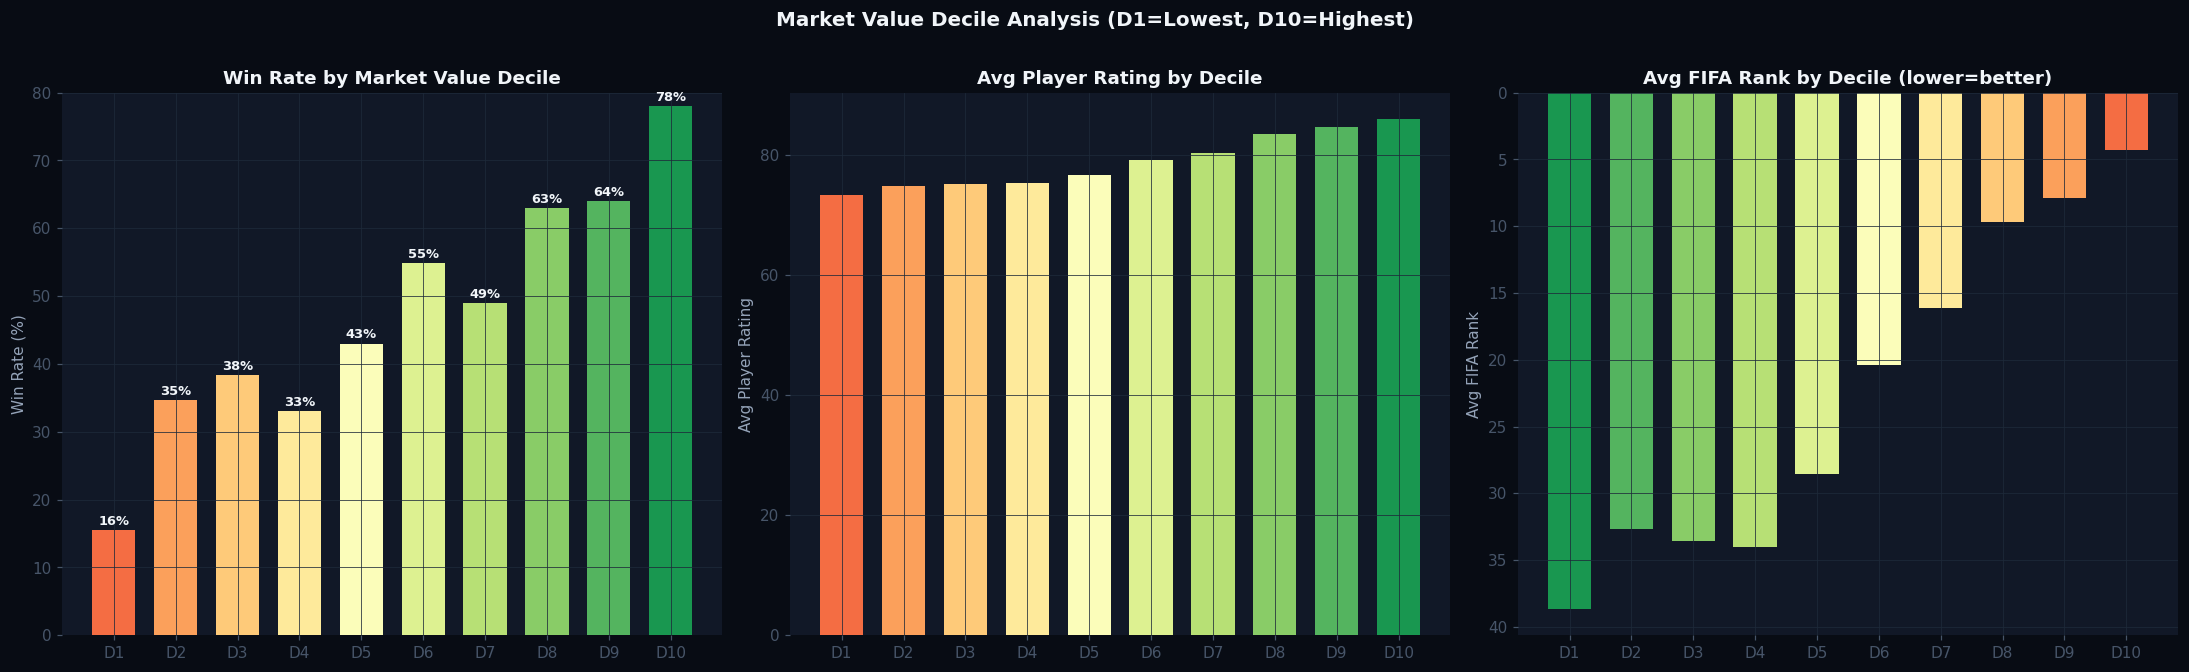

           win_pct  avg_rating  avg_rank  mv_min  mv_max  count
mv_decile                                                      
D1            15.5      73.238    38.689   200.0   258.0    103
D2            34.7      74.741    32.684   259.0   290.0     98
D3            38.4      75.093    33.535   291.0   323.0     99
D4            33.0      75.325    34.010   324.0   362.0    100
D5            43.0      76.582    28.520   363.0   435.0    100
D6            54.9      79.071    20.402   437.0   506.0    102
D7            49.0      80.192    16.102   507.0   617.0     98
D8            63.0      83.396     9.670   625.0   752.0    100
D9            64.0      84.559     7.890   754.0   907.0    100
D10           78.0      86.000     4.270   908.0  1198.0    100


In [12]:
# ── Market Value Decile Analysis ──────────────────────────────────────────────
train['mv_decile'] = pd.qcut(train['market_value_million_eur'], q=10,
                              labels=[f'D{i}' for i in range(1,11)])
decile_stats = train.groupby('mv_decile', observed=True).agg(
    win_rate  = ('winner',                   'mean'),
    avg_rating= ('avg_player_rating',        'mean'),
    avg_rank  = ('fifa_rank',                'mean'),
    count     = ('team_name',                'count'),
    mv_min    = ('market_value_million_eur', 'min'),
    mv_max    = ('market_value_million_eur', 'max'),
).round(3)
decile_stats['win_pct'] = (decile_stats['win_rate'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Market Value Decile Analysis (D1=Lowest, D10=Highest)',
             fontsize=13, fontweight='bold', y=1.01)

decile_wr = decile_stats['win_pct']
colors_d  = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 10))
axes[0].bar(decile_stats.index, decile_wr, color=colors_d, edgecolor='none', width=0.7)
axes[0].set_title('Win Rate by Market Value Decile', fontweight='bold')
axes[0].set_ylabel('Win Rate (%)');  axes[0].set_ylim(0, 80)
for i, val in enumerate(decile_wr):
    axes[0].text(i, val+0.8, f'{val:.0f}%', ha='center', fontsize=8.5, fontweight='bold', color=TXT)

axes[1].bar(decile_stats.index, decile_stats['avg_rating'], color=colors_d, edgecolor='none', width=0.7)
axes[1].set_title('Avg Player Rating by Decile', fontweight='bold')
axes[1].set_ylabel('Avg Player Rating')

axes[2].bar(decile_stats.index, decile_stats['avg_rank'], color=colors_d[::-1], edgecolor='none', width=0.7)
axes[2].set_title('Avg FIFA Rank by Decile (lower=better)', fontweight='bold')
axes[2].set_ylabel('Avg FIFA Rank')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print(decile_stats[['win_pct','avg_rating','avg_rank','mv_min','mv_max','count']].to_string())


## 6 · Outlier Detection — Multi-Method


Multi-Method Outlier Detection:
                 Feature  IQR outliers  Z>3 outliers  ModZ outliers   Min     Max  Skewness
market_value_million_eur             0             0              0 200.0 1198.00     0.923
       avg_player_rating             0             0              0  70.0   90.00     0.203
               fifa_rank             0             0              0   1.0   50.00     0.259
        goals_scored_avg             0             0              0   0.5    2.80     0.394
      win_rate_last_year             0             0              0   0.2    0.85    -0.028
          shots_per_game             0             0              0   6.0   20.00     0.249
     experience_avg_caps             0             0              0  15.0   65.00     0.267
  coach_experience_years             0             0              0   1.0   25.00     0.638


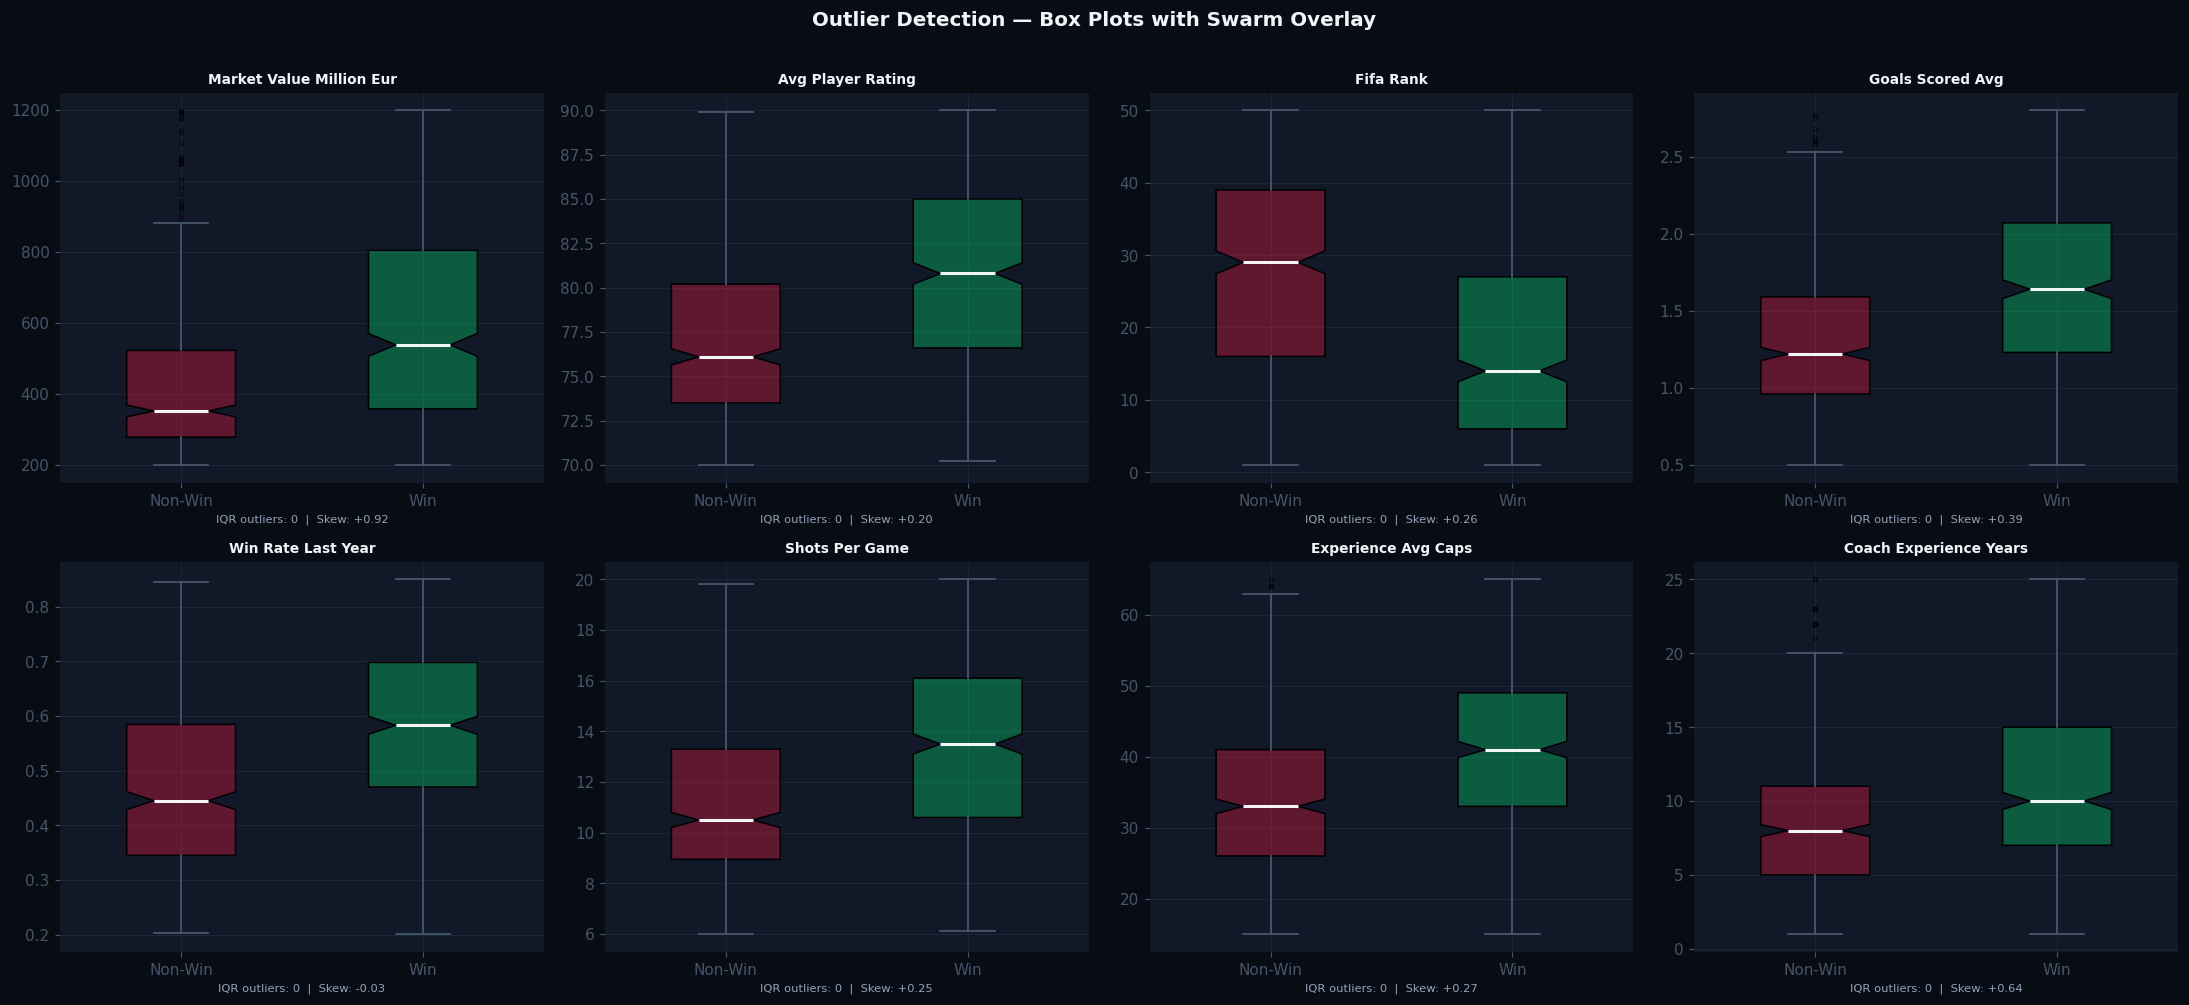

Strategy: RobustScaler in ML pipeline handles outliers gracefully without removal.


In [13]:
# ── IQR + Z-Score + Modified Z-Score ─────────────────────────────────────────
from scipy.stats import zscore

outlier_summary = []
for col in ['market_value_million_eur','avg_player_rating','fifa_rank',
            'goals_scored_avg','win_rate_last_year','shots_per_game',
            'experience_avg_caps','coach_experience_years']:
    data = train[col].dropna()
    Q1, Q3 = data.quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    iqr_mask = (data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)

    zs = np.abs(zscore(data))
    z_mask  = zs > 3

    med   = data.median()
    mad   = np.median(np.abs(data - med))
    mz    = 0.6745 * (data - med) / (mad + 1e-9)
    mz_mask = np.abs(mz) > 3.5

    outlier_summary.append({
        'Feature':       col,
        'IQR outliers':  int(iqr_mask.sum()),
        'Z>3 outliers':  int(z_mask.sum()),
        'ModZ outliers': int(mz_mask.sum()),
        'Min':           round(data.min(), 2),
        'Max':           round(data.max(), 2),
        'Skewness':      round(skew(data), 3),
    })

out_df = pd.DataFrame(outlier_summary)
print('Multi-Method Outlier Detection:')
print(out_df.to_string(index=False))

# Visualise
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Outlier Detection — Box Plots with Swarm Overlay',
             fontsize=13, fontweight='bold', y=1.01)

for ax, row_d in zip(axes.flat, outlier_summary):
    col  = row_d['Feature']
    data = train[col].dropna()
    w0   = train[train['winner']==0][col].dropna()
    w1   = train[train['winner']==1][col].dropna()

    bp = ax.boxplot([w0, w1], patch_artist=True, widths=0.45, notch=True,
                    medianprops=dict(color=TXT, linewidth=2),
                    whiskerprops=dict(color=MUTED, linewidth=1.2),
                    capprops=dict(color=MUTED, linewidth=1.2),
                    flierprops=dict(marker='.', color=C_RED, alpha=0.5, markersize=5))
    bp['boxes'][0].set_facecolor(C_RED + '55')
    bp['boxes'][1].set_facecolor(C_GREEN + '55')
    ax.set_xticklabels(['Non-Win', 'Win'])
    ax.set_title(col.replace('_',' ').title(), fontsize=9, fontweight='bold')
    iqr_n = row_d['IQR outliers']
    ax.set_xlabel(f'IQR outliers: {iqr_n}  |  Skew: {row_d["Skewness"]:+.2f}', fontsize=7.5, color=SUB)

plt.tight_layout()
plt.show()
print('Strategy: RobustScaler in ML pipeline handles outliers gracefully without removal.')


## 7 · Pairwise Feature Interactions


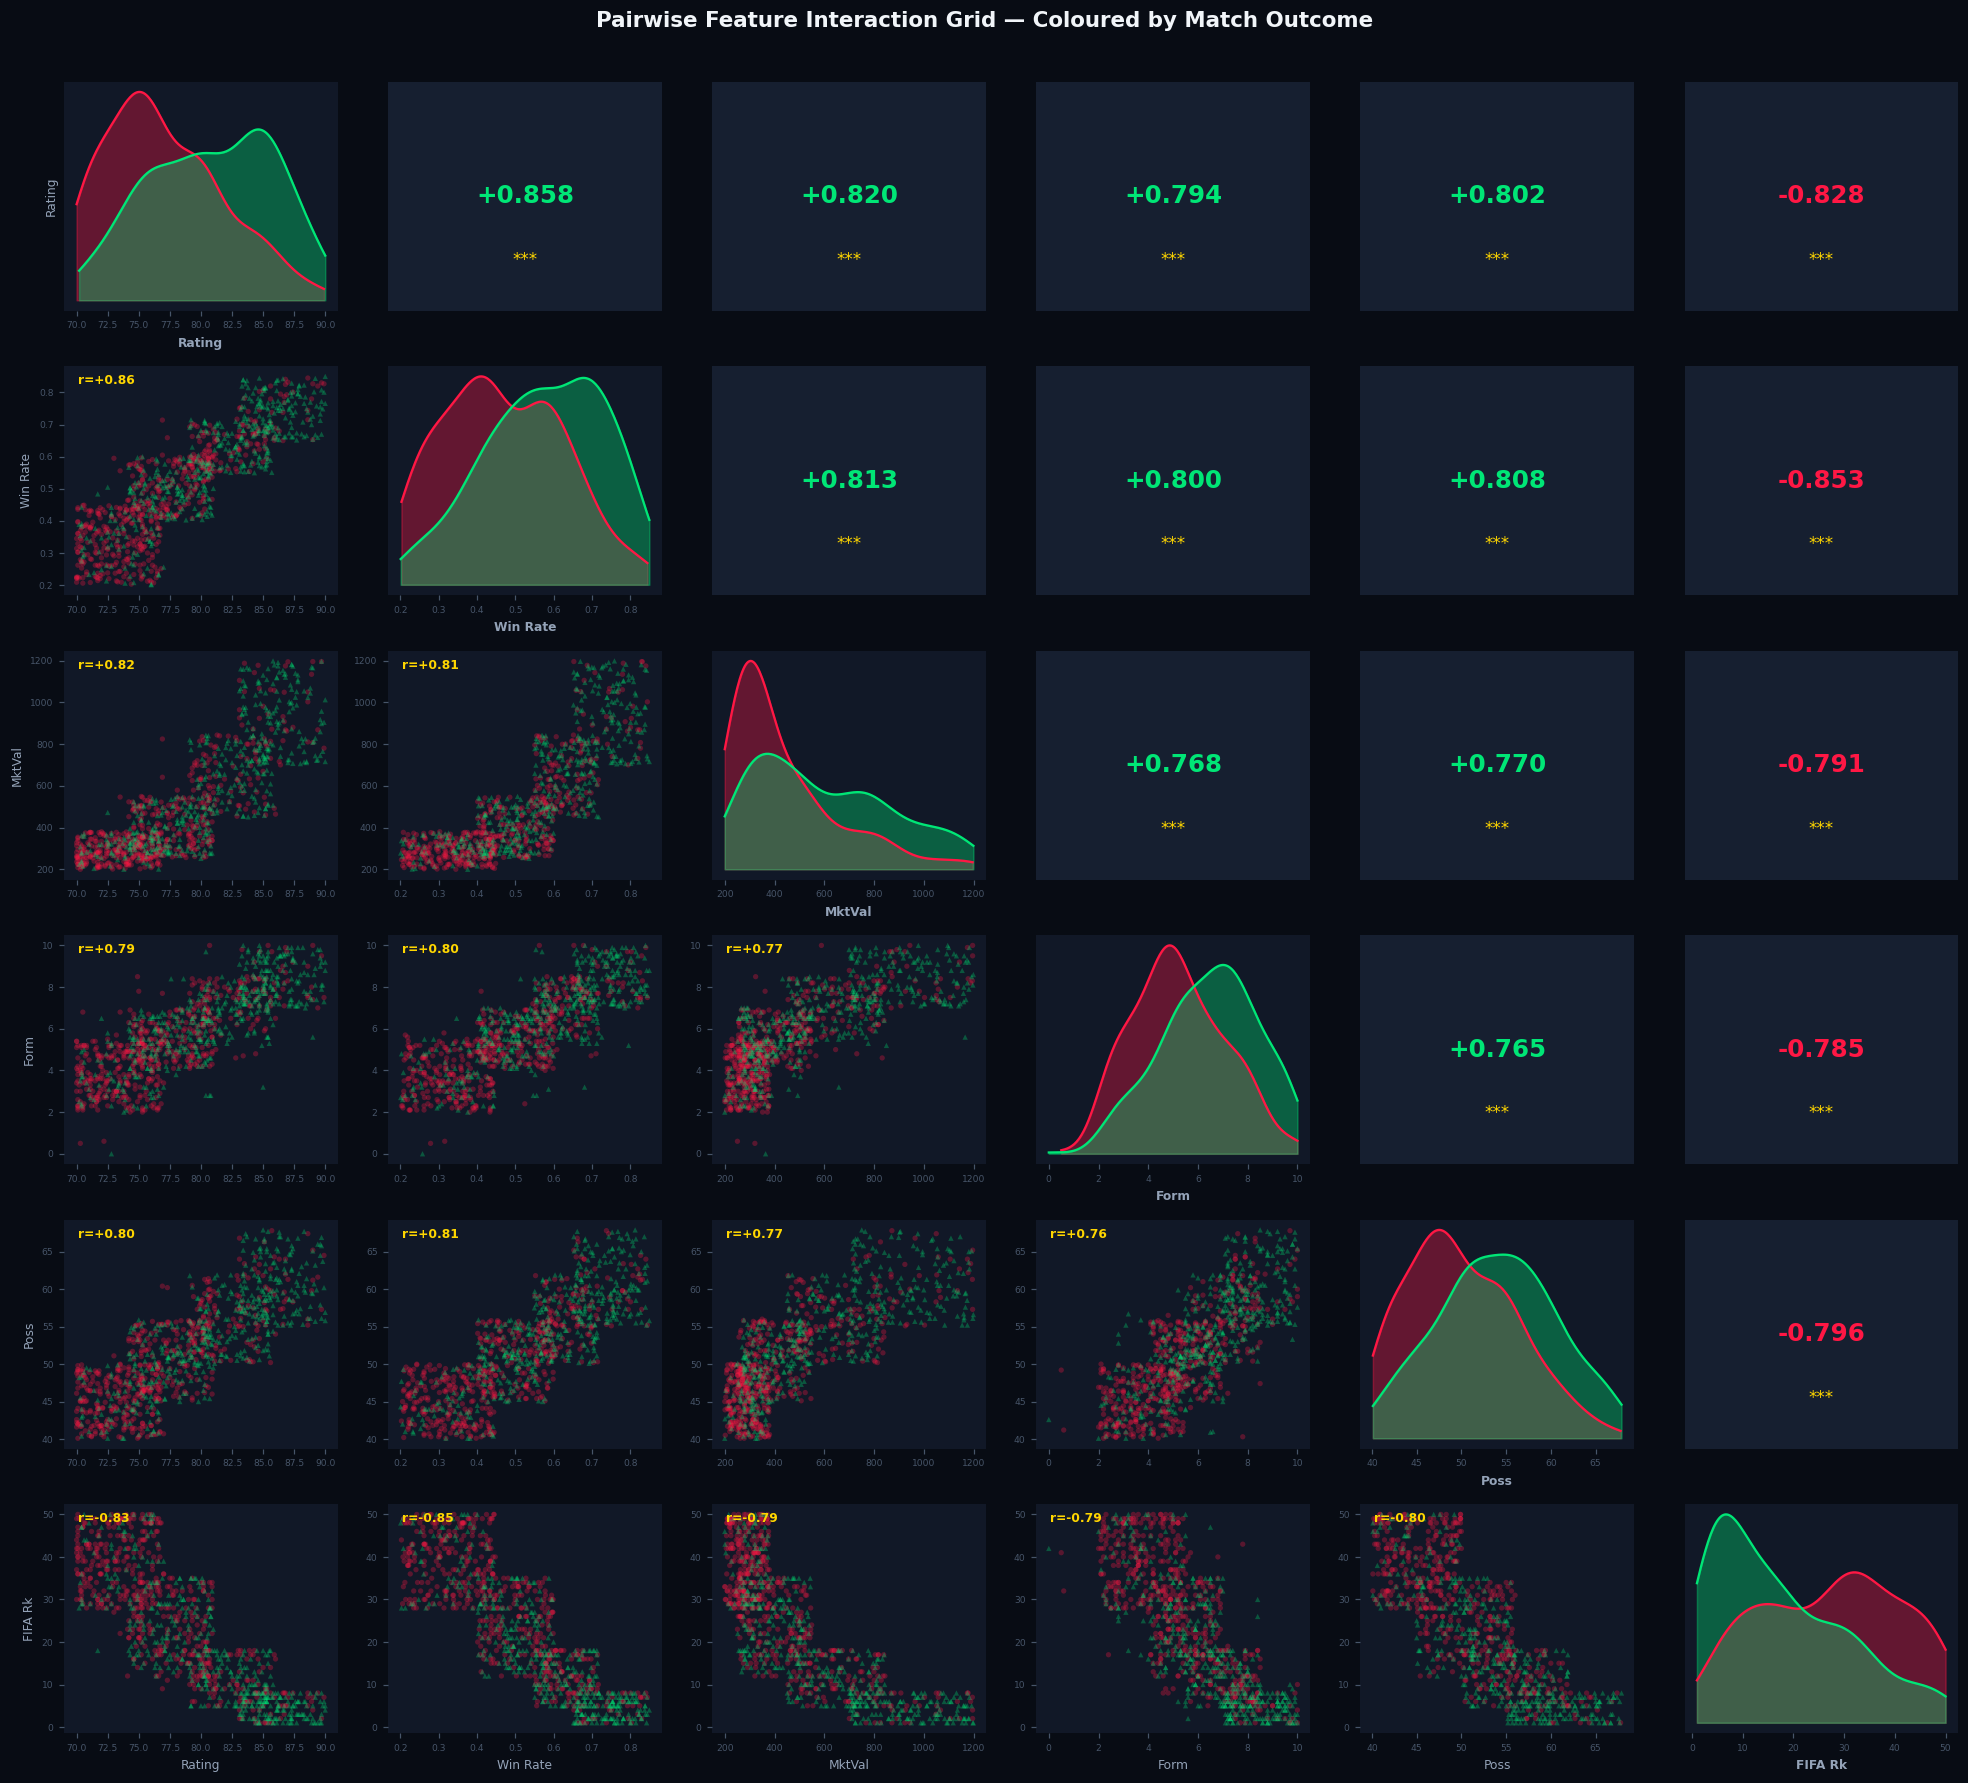

In [14]:
# ── Top Feature Pair Scatter Grid ────────────────────────────────────────────
top_features = ['avg_player_rating', 'win_rate_last_year', 'market_value_million_eur',
                'recent_form_score', 'possession_avg', 'fifa_rank']
labels_short = ['Rating', 'Win Rate', 'MktVal', 'Form', 'Poss', 'FIFA Rk']

n = len(top_features)
fig, axes = plt.subplots(n, n, figsize=(18, 16))
fig.suptitle('Pairwise Feature Interaction Grid — Coloured by Match Outcome',
             fontsize=14, fontweight='bold', y=1.01)

for i, (fi, li) in enumerate(zip(top_features, labels_short)):
    for j, (fj, lj) in enumerate(zip(top_features, labels_short)):
        ax = axes[i, j]
        if i == j:
            # Diagonal: KDE by class
            for label, color in [(0, C_RED), (1, C_GREEN)]:
                d = train[train['winner']==label][fi].dropna()
                from scipy.stats import gaussian_kde
                if len(d) > 5:
                    kde = gaussian_kde(d, bw_method=0.35)
                    xs  = np.linspace(d.min(), d.max(), 200)
                    ax.fill_between(xs, kde(xs), alpha=0.35, color=color)
                    ax.plot(xs, kde(xs), color=color, linewidth=1.5)
            ax.set_xlabel(li, fontsize=8, fontweight='bold')
            ax.set_yticks([])
        elif i > j:
            # Lower triangle: scatter
            for label, color, mk in [(0, C_RED, 'o'), (1, C_GREEN, '^')]:
                g = train[train['winner']==label]
                ax.scatter(g[fj], g[fi], color=color, alpha=0.3, s=12,
                           marker=mk, edgecolors='none')
            r, _ = stats.pearsonr(train[fj].fillna(0), train[fi].fillna(0))
            ax.text(0.05, 0.92, f'r={r:+.2f}', transform=ax.transAxes,
                    fontsize=8, color=C_GOLD, fontweight='bold')
        else:
            # Upper triangle: text correlation
            r, p = stats.pearsonr(train[fj].fillna(0), train[fi].fillna(0))
            ax.set_facecolor(CARD2)
            ax.text(0.5, 0.5, f'{r:+.3f}',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=16, fontweight='black',
                    color=C_GREEN if r > 0.3 else C_RED if r < -0.3 else TXT)
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            ax.text(0.5, 0.2, sig, ha='center', transform=ax.transAxes,
                    fontsize=11, color=C_GOLD)
            ax.set_xticks([]); ax.set_yticks([])

        if i == n-1: ax.set_xlabel(lj, fontsize=8)
        if j == 0:   ax.set_ylabel(li, fontsize=8)
        ax.tick_params(labelsize=6)
        ax.grid(False)

plt.tight_layout()
plt.show()


## 8 · PCA — Dimensionality Reduction & Clustering


Components to explain 80% variance: 4
PC1 explains: 61.3%
PC2 explains: 12.3%


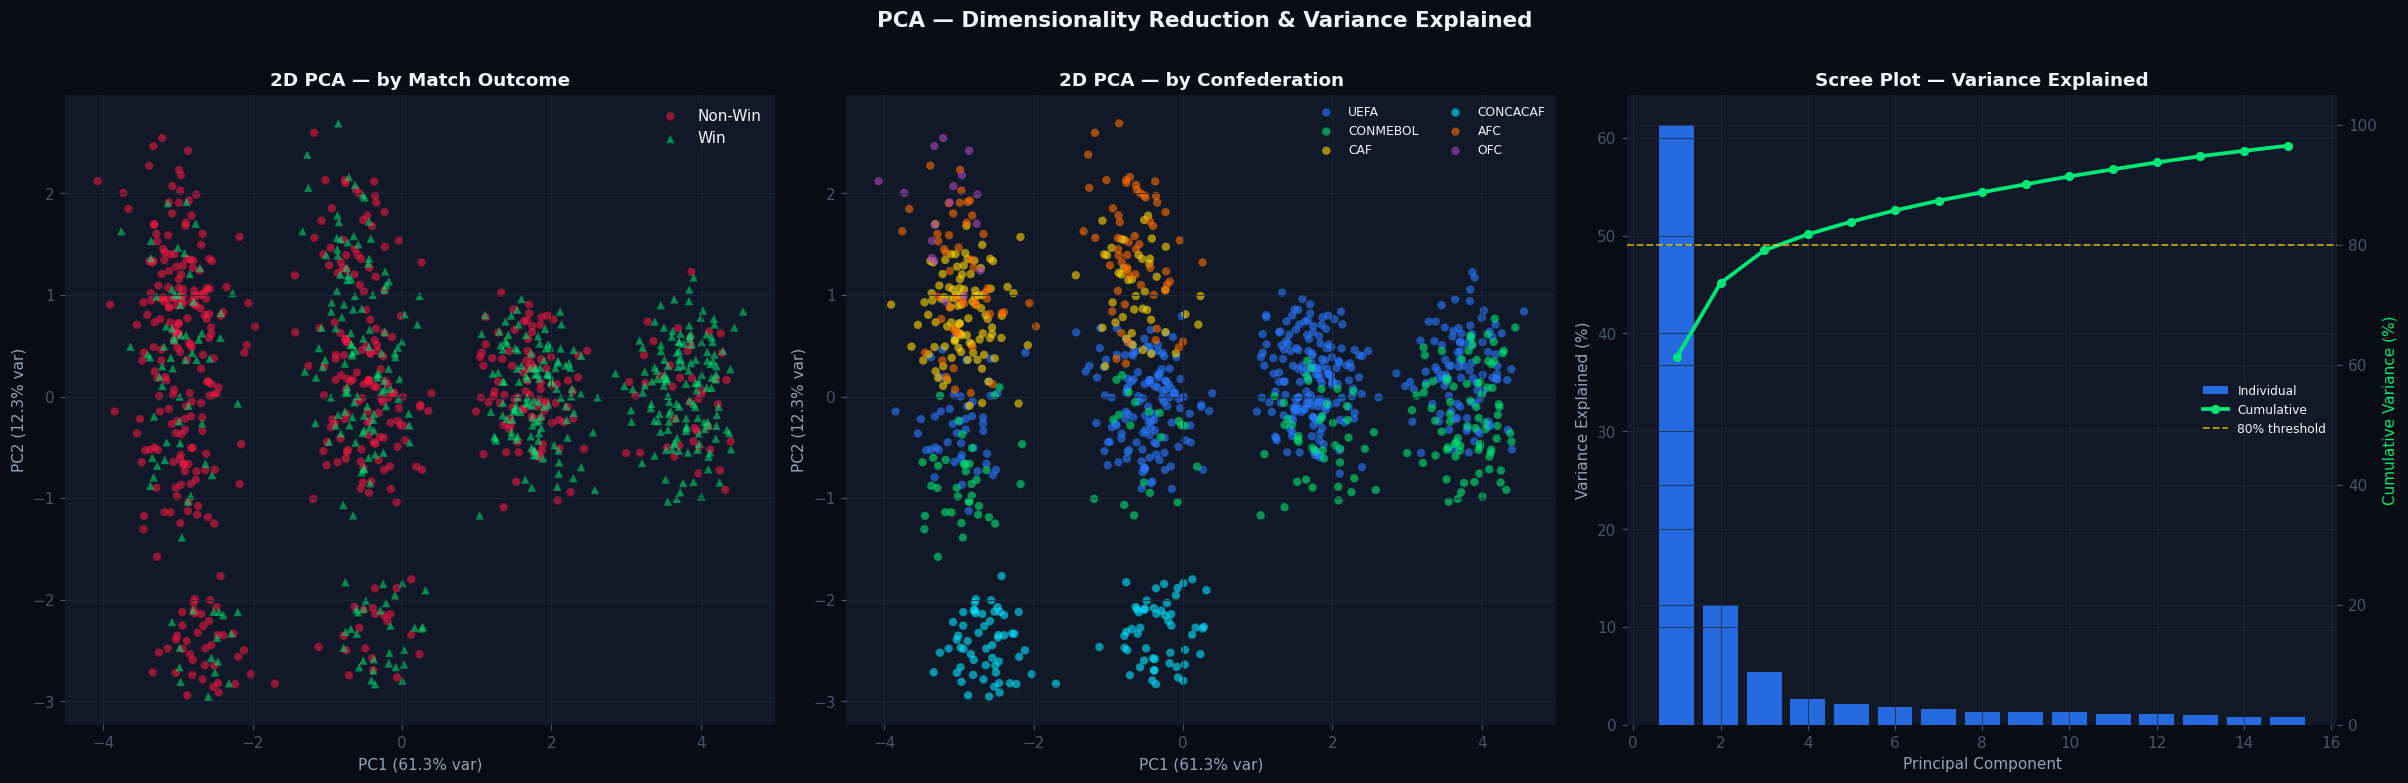

In [15]:
# ── PCA — 2D & 3D Visualisation ──────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler as RS

X_pca = train[NUM_COLS].fillna(train[NUM_COLS].median())
scaler = RS()
X_scaled = scaler.fit_transform(X_pca)

pca2 = PCA(n_components=2, random_state=42)
pca3 = PCA(n_components=3, random_state=42)
coords2 = pca2.fit_transform(X_scaled)
coords3 = pca3.fit_transform(X_scaled)

pca_full = PCA(random_state=42).fit(X_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('PCA — Dimensionality Reduction & Variance Explained',
             fontsize=14, fontweight='bold', y=1.01)

# Left — 2D by winner
for label, color, marker, name in [(0, C_RED,'o','Non-Win'), (1, C_GREEN,'^','Win')]:
    mask = train['winner'] == label
    axes[0].scatter(coords2[mask, 0], coords2[mask, 1],
                    c=color, alpha=0.55, s=30, marker=marker,
                    label=name, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('2D PCA — by Match Outcome', fontweight='bold')
axes[0].legend(fontsize=10)

# Middle — 2D by confederation
conf_enc = {c: i for i, c in enumerate(train['confederation'].unique())}
conf_arr = train['confederation'].map(conf_enc).values
conf_palette = list(CONF_COLORS.values())[:6]
for c_name, c_code in conf_enc.items():
    mask = train['confederation'] == c_name
    axes[1].scatter(coords2[mask, 0], coords2[mask, 1],
                    c=CONF_COLORS.get(c_name, MUTED), alpha=0.6, s=30,
                    label=c_name, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('2D PCA — by Confederation', fontweight='bold')
axes[1].legend(fontsize=8, ncol=2)

# Right — scree plot + cumulative variance
bars = axes[2].bar(range(1, min(16,len(pca_full.explained_variance_ratio_)+1)),
                   pca_full.explained_variance_ratio_[:15]*100,
                   color=C_BLUE, edgecolor='none', alpha=0.85, label='Individual')
ax2 = axes[2].twinx()
ax2.plot(range(1, min(16,len(cumvar)+1)), cumvar[:15]*100,
         color=C_GREEN, linewidth=2.5, marker='o', markersize=5, label='Cumulative')
ax2.axhline(80, color=C_GOLD, linewidth=1.2, linestyle='--', alpha=0.7, label='80% threshold')
ax2.set_ylabel('Cumulative Variance (%)', color=C_GREEN)
ax2.set_ylim(0, 105)
axes[2].set_xlabel('Principal Component'); axes[2].set_ylabel('Variance Explained (%)')
axes[2].set_title('Scree Plot — Variance Explained', fontweight='bold')
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[2].legend(lines1+lines2, labels1+labels2, fontsize=8, loc='center right')

n80 = int(np.argmax(cumvar >= 0.80)) + 1
print(f'Components to explain 80% variance: {n80}')
print(f'PC1 explains: {pca_full.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 explains: {pca_full.explained_variance_ratio_[1]*100:.1f}%')
plt.tight_layout()
plt.show()


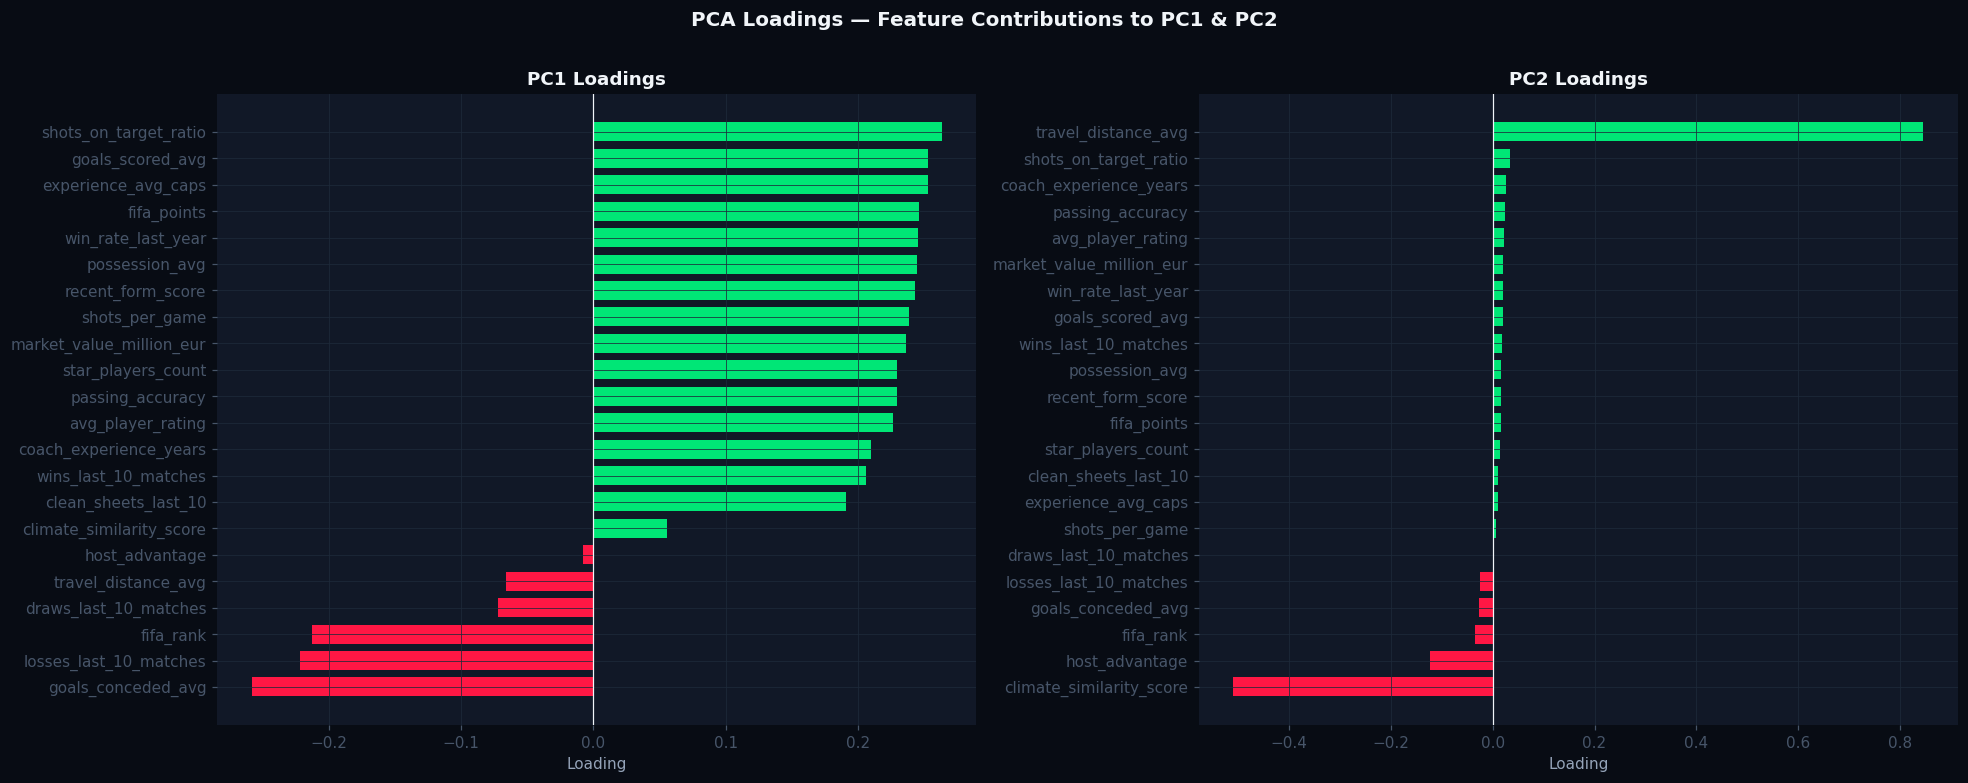

Top PC1 contributors (positive = correlated with PC1):
shots_on_target_ratio    0.2629
goals_conceded_avg       0.2580
goals_scored_avg         0.2525
experience_avg_caps      0.2522
fifa_points              0.2454
win_rate_last_year       0.2448
possession_avg           0.2442
recent_form_score        0.2429


In [16]:
# ── PCA Loadings — Feature Contribution ─────────────────────────────────────
pca_load = pd.DataFrame(
    pca2.components_.T,
    index=NUM_COLS,
    columns=['PC1', 'PC2']
).round(4)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('PCA Loadings — Feature Contributions to PC1 & PC2',
             fontsize=13, fontweight='bold', y=1.01)

for ax, pc in [( axes[0], 'PC1'), (axes[1], 'PC2')]:
    sorted_load = pca_load[pc].sort_values()
    bar_c = [C_GREEN if v > 0 else C_RED for v in sorted_load.values]
    ax.barh(sorted_load.index, sorted_load.values, color=bar_c, edgecolor='none', height=0.72)
    ax.axvline(0, color=TXT, linewidth=0.8)
    ax.set_title(f'{pc} Loadings', fontweight='bold', fontsize=12)
    ax.set_xlabel('Loading')

plt.tight_layout()
plt.show()

print('Top PC1 contributors (positive = correlated with PC1):')
print(pca_load['PC1'].abs().sort_values(ascending=False).head(8).to_string())


## 9 · Statistical Hypothesis Tests — Win vs Non-Win


In [17]:
# ── Full Hypothesis Test Battery ─────────────────────────────────────────────
from scipy.stats import mannwhitneyu, ttest_ind, levene, bartlett

print('Statistical Hypothesis Tests — Winners vs Non-Winners')
print('=' * 85)
print(f'{"Feature":<32} {"t-stat":>7} {"t-p":>8} {"MWU-p":>8} {"Effect d":>9} {"Levene-p":>9} {"Sig"}')
print('-' * 85)

results = []
for col in NUM_COLS:
    w0 = train[train['winner']==0][col].dropna()
    w1 = train[train['winner']==1][col].dropna()
    if len(w0) < 5 or len(w1) < 5: continue

    t_stat, t_p = ttest_ind(w0, w1)
    u_stat, u_p = mannwhitneyu(w0, w1, alternative='two-sided')
    lev_stat, lev_p = levene(w0, w1)

    # Cohen's d
    pooled_std = np.sqrt((w0.std()**2 + w1.std()**2) / 2 + 1e-9)
    d = (w1.mean() - w0.mean()) / pooled_std

    sig = '***' if t_p < 0.001 else '**' if t_p < 0.01 else '*' if t_p < 0.05 else 'ns'
    results.append({'Feature': col, 't_stat': t_stat, 't_p': t_p, 'u_p': u_p,
                    'cohens_d': d, 'lev_p': lev_p, 'sig': sig})
    print(f'{col:<32} {t_stat:>7.3f} {t_p:>8.4f} {u_p:>8.4f} {d:>9.4f} {lev_p:>9.4f} {sig}')

print()
results_df = pd.DataFrame(results).sort_values('cohens_d', key=abs, ascending=False)
print("Top 10 features by Cohen's d (effect size):")
print(results_df[['Feature','cohens_d','sig']].head(10).to_string(index=False))


Statistical Hypothesis Tests — Winners vs Non-Winners
Feature                           t-stat      t-p    MWU-p  Effect d  Levene-p Sig
-------------------------------------------------------------------------------------
fifa_rank                         11.867   0.0000   0.0000   -0.7525    0.0607 ***
fifa_points                      -10.919   0.0000   0.0000    0.6890    0.0001 ***
wins_last_10_matches              -9.375   0.0000   0.0000    0.5936    0.9504 ***
losses_last_10_matches             9.307   0.0000   0.0000   -0.5898    0.8918 ***
draws_last_10_matches              2.600   0.0095   0.0166   -0.1650    0.3063 **
win_rate_last_year               -11.160   0.0000   0.0000    0.7069    0.8891 ***
goals_scored_avg                 -11.995   0.0000   0.0000    0.7570    0.0001 ***
goals_conceded_avg                10.230   0.0000   0.0000   -0.6503    0.0000 ***
clean_sheets_last_10             -10.269   0.0000   0.0000    0.6491    0.0199 ***
shots_per_game                 

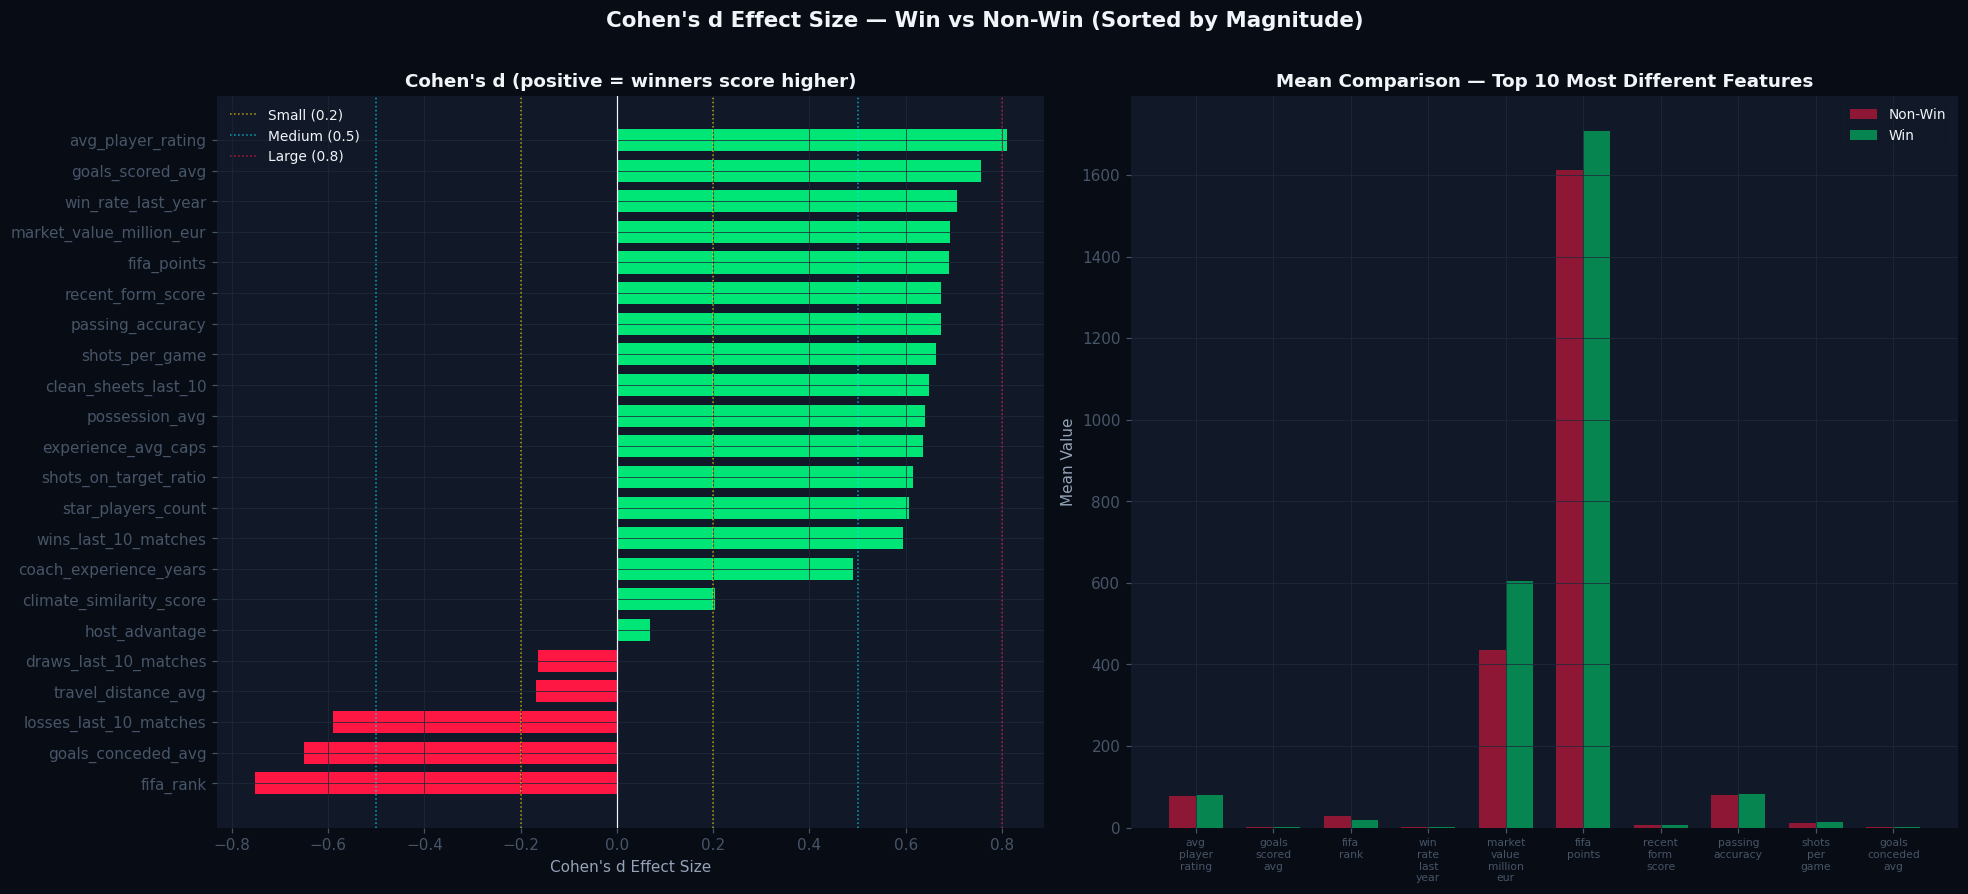

In [18]:
# ── Effect Size Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Cohen's d Effect Size — Win vs Non-Win (Sorted by Magnitude)",
             fontsize=14, fontweight='bold', y=1.01)

sorted_d = results_df.sort_values('cohens_d')
bar_c = [C_GREEN if v > 0 else C_RED for v in sorted_d['cohens_d']]
axes[0].barh(sorted_d['Feature'], sorted_d['cohens_d'],
             color=bar_c, edgecolor='none', height=0.72)
axes[0].axvline(0,    color=TXT,    linewidth=0.8)
axes[0].axvline(0.2,  color=C_GOLD, linewidth=1, linestyle=':', alpha=0.7, label='Small (0.2)')
axes[0].axvline(-0.2, color=C_GOLD, linewidth=1, linestyle=':', alpha=0.7)
axes[0].axvline(0.5,  color=C_CYAN, linewidth=1, linestyle=':', alpha=0.7, label='Medium (0.5)')
axes[0].axvline(-0.5, color=C_CYAN, linewidth=1, linestyle=':', alpha=0.7)
axes[0].axvline(0.8,  color=C_RED,  linewidth=1, linestyle=':', alpha=0.7, label='Large (0.8)')
axes[0].set_title("Cohen's d (positive = winners score higher)", fontweight='bold')
axes[0].set_xlabel("Cohen's d Effect Size")
axes[0].legend(fontsize=9)

# Right — mean difference visualisation
top_diff = results_df.head(10)
w0_means = [train[train['winner']==0][f].mean() for f in top_diff['Feature']]
w1_means = [train[train['winner']==1][f].mean() for f in top_diff['Feature']]

x = np.arange(len(top_diff))
w = 0.35
axes[1].bar(x - w/2, w0_means, w, color=C_RED+'88', label='Non-Win', edgecolor='none')
axes[1].bar(x + w/2, w1_means, w, color=C_GREEN+'88', label='Win', edgecolor='none')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f.replace('_','\n') for f in top_diff['Feature']], fontsize=7)
axes[1].set_title('Mean Comparison — Top 10 Most Different Features', fontweight='bold')
axes[1].set_ylabel('Mean Value')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 10 · Engineered Feature Validation


2026-06-04 11:34:02,965 - INFO - Feature engineering complete — added 10 derived features


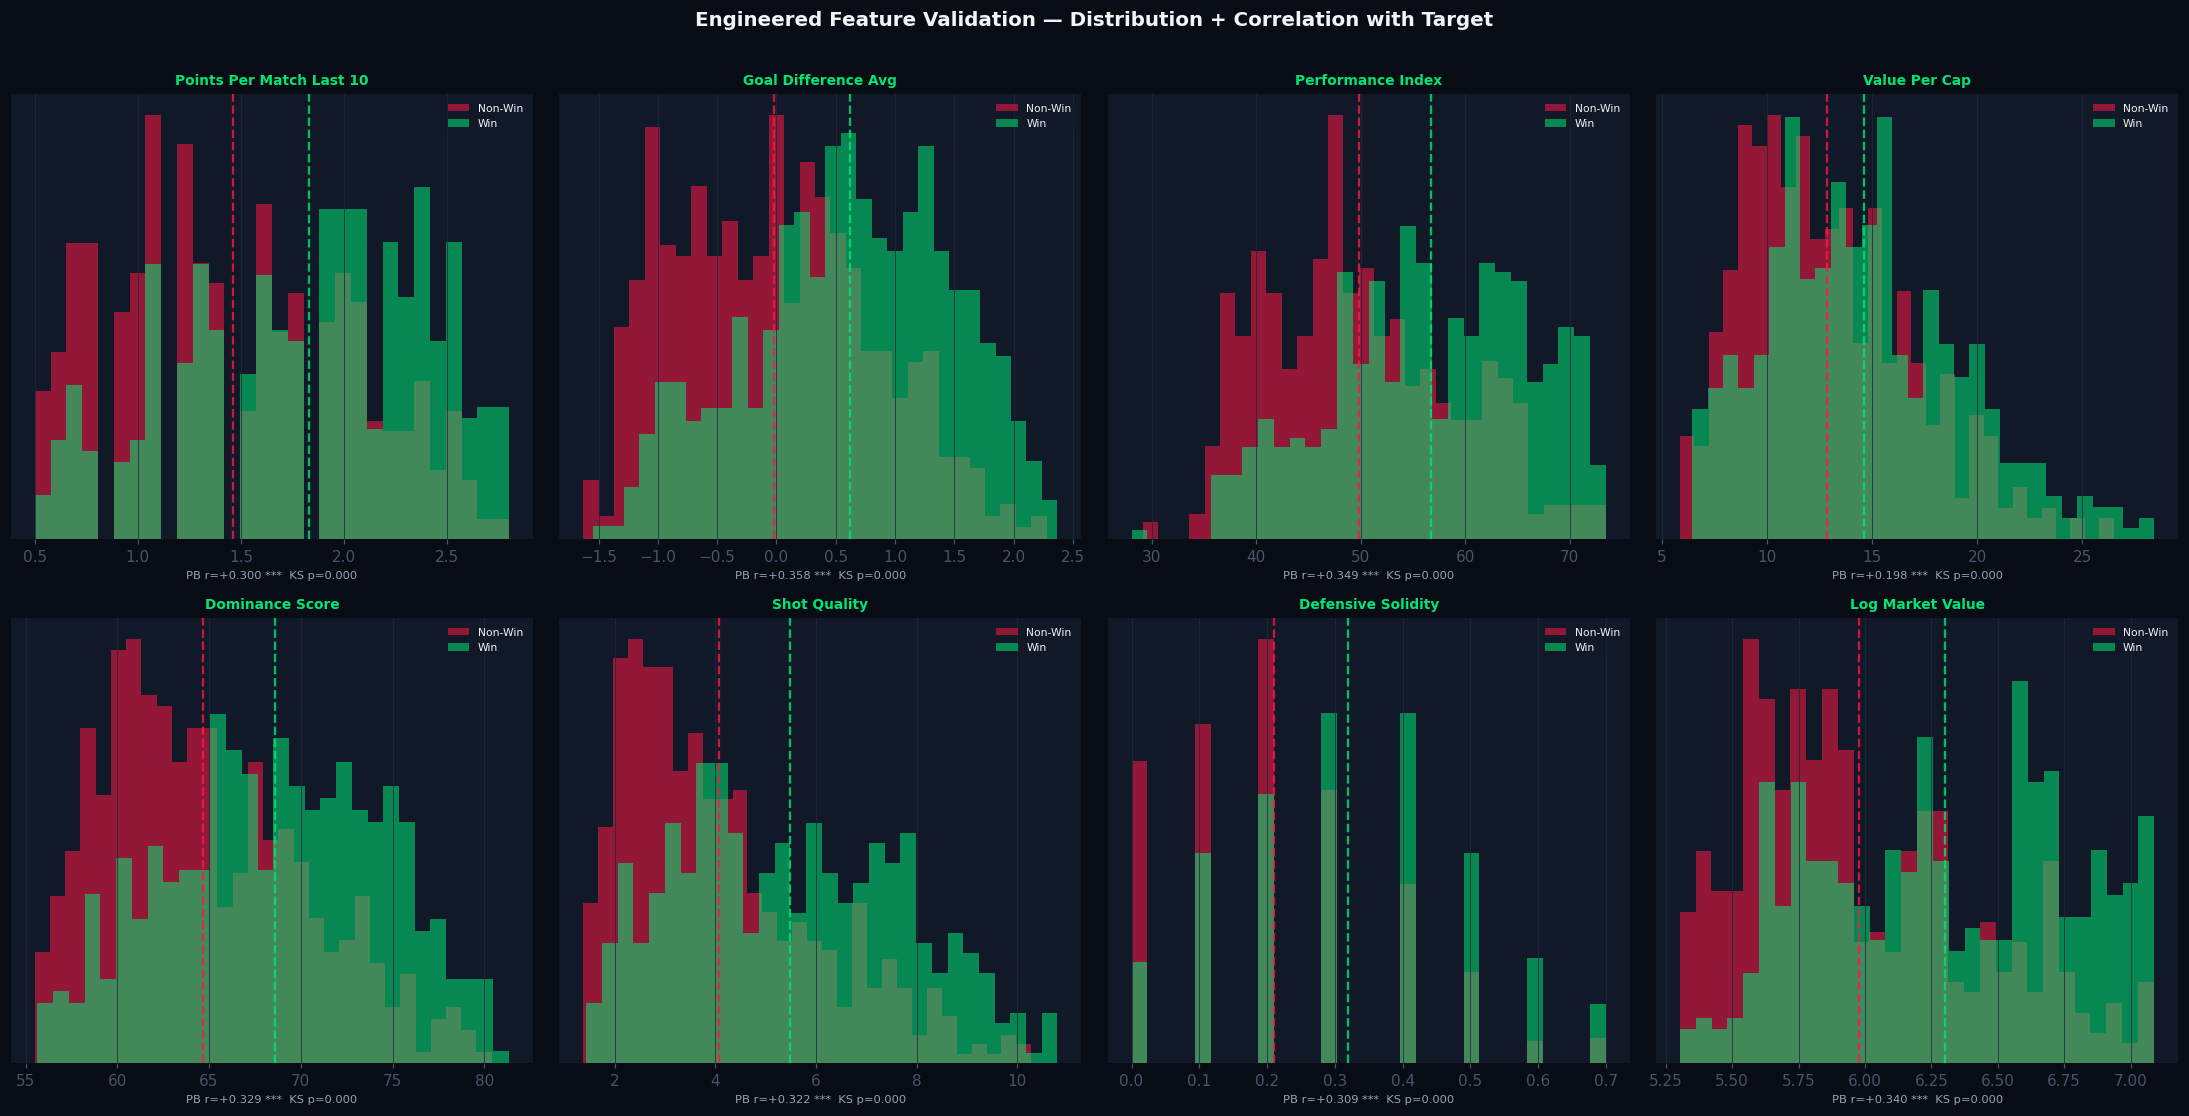

Engineered Feature Correlations with Target:
  points_per_match_last_10            r=+0.3001  ***
  goal_difference_avg                 r=+0.3584  ***
  performance_index                   r=+0.3490  ***
  value_per_cap                       r=+0.1977  ***
  dominance_score                     r=+0.3294  ***
  shot_quality                        r=+0.3221  ***
  defensive_solidity                  r=+0.3091  ***
  log_market_value                    r=+0.3405  ***


In [19]:
# ── Validate Engineered Features ─────────────────────────────────────────────
import sys; sys.path.insert(0,'../src')
from data_preprocessing import clean_and_process

train_fe = clean_and_process(train.copy(), is_train=True)
train_fe['winner'] = train['winner'].values

engineered = ['points_per_match_last_10','goal_difference_avg','performance_index',
              'value_per_cap','dominance_score','shot_quality','defensive_solidity','log_market_value']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Engineered Feature Validation — Distribution + Correlation with Target',
             fontsize=13, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flat, engineered):
    if feat not in train_fe.columns:
        ax.set_visible(False); continue
    w0 = train_fe[train_fe['winner']==0][feat].dropna()
    w1 = train_fe[train_fe['winner']==1][feat].dropna()
    r, p = pointbiserialr(train_fe['winner'], train_fe[feat].fillna(0))
    _, ks_p = ks_2samp(w0, w1)

    ax.hist(w0, bins=30, density=True, alpha=0.55, color=C_RED,   label='Non-Win', edgecolor='none')
    ax.hist(w1, bins=30, density=True, alpha=0.55, color=C_GREEN, label='Win',     edgecolor='none')
    ax.axvline(w0.mean(), color=C_RED+'cc',   linewidth=1.5, linestyle='--')
    ax.axvline(w1.mean(), color=C_GREEN+'cc', linewidth=1.5, linestyle='--')

    title_color = C_GREEN if abs(r) > 0.1 else MUTED
    ax.set_title(feat.replace('_',' ').title(), fontsize=9, fontweight='bold', color=title_color)
    sig_str = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlabel(f'PB r={r:+.3f} {sig_str}  KS p={ks_p:.3f}', fontsize=7.5, color=SUB)
    ax.legend(fontsize=7)
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print('Engineered Feature Correlations with Target:')
for feat in engineered:
    if feat in train_fe.columns:
        r, p = pointbiserialr(train_fe['winner'], train_fe[feat].fillna(0))
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        print(f'  {feat:<35} r={r:+.4f}  {sig}')


## 11 · Key Insights Summary


In [20]:
# ── Comprehensive Insight Summary ────────────────────────────────────────────
best_conf  = conf_wr.idxmax()
worst_conf = conf_wr.idxmin()
most_sig   = results_df.iloc[0]
most_mi    = mi_df.iloc[0]
uv_count   = len(train[train['quadrant'] == 'Undervalued'])
ov_count   = len(train[train['quadrant'] == 'Overvalued'])

r_mv, _    = stats.pearsonr(train['market_value_million_eur'], train['win_rate_last_year'])
home_wr    = train[train['host_advantage'] == 1]['winner'].mean() * 100
away_wr    = train[train['host_advantage'] == 0]['winner'].mean() * 100
elite_wr   = train[train['avg_player_rating'] >= 85]['winner'].mean() * 100
non_elite  = train[train['avg_player_rating'] <  85]['winner'].mean() * 100

best_wr_str  = str(best_conf)  + ' leads at '  + f'{conf_wr[best_conf]:.1f}%'
worst_wr_str = str(worst_conf) + ' lags at '   + f'{conf_wr[worst_conf]:.1f}%'
sig_str      = str(most_sig['Feature']) + ' — d=' + f'{most_sig["cohens_d"]:+.3f} ({most_sig["sig"]})'
mi_str       = str(most_mi['feature']) + ' — MI=' + f'{most_mi["MI"]:.4f}'
mv_r_str     = f'r={r_mv:.3f}  R2={r_mv**2:.3f}  explains {r_mv**2*100:.1f}% variance'
home_str     = f'{home_wr:.1f}% home  vs  {away_wr:.1f}% away  (+{home_wr - away_wr:.1f}pp)'
elite_str    = f'Rating>=85: {elite_wr:.1f}%  vs  {non_elite:.1f}% others (+{elite_wr-non_elite:.1f}pp)'

insights = [
    ('Class Balance',         f'{train["winner"].mean()*100:.1f}% wins — balanced, no resampling needed'),
    ('Best Confederation',    best_wr_str),
    ('Weakest Confederation', worst_wr_str),
    ('Strongest Predictor',   sig_str),
    ('Best MI Signal',        mi_str),
    ('Market Value r',        mv_r_str),
    ('Home Advantage',        home_str),
    ('Elite Teams',           elite_str),
    ('Undervalued Teams',     str(uv_count) + ' teams: high win rate, below-median budget'),
    ('Overvalued Teams',      str(ov_count) + ' teams: low win rate, above-median budget'),
    ('PCA Components',        str(n80) + ' components explain 80% of variance'),
    ('Normality',             'Most features non-normal: RobustScaler + tree models preferred'),
    ('Outlier Strategy',      'IQR outliers in market_value & caps: handled by RobustScaler'),
]

print()
print('=' * 78)
print('   ScoutIQ Advanced EDA — Key Intelligence Findings')
print('=' * 78)
for k, v in insights:
    print(f'  {k:<25}  {v}')
print('=' * 78)
print('  Next: 03_Model_Development_and_Evaluation.ipynb')
print('=' * 78)

train.drop(columns=['quadrant', 'mv_decile'], errors='ignore', inplace=True)



   ScoutIQ Advanced EDA — Key Intelligence Findings
  Class Balance              47.3% wins — balanced, no resampling needed
  Best Confederation         CONMEBOL leads at 55.0%
  Weakest Confederation      OFC lags at 17.6%
  Strongest Predictor        avg_player_rating — d=+0.810 (***)
  Best MI Signal             wins_last_10_matches — MI=0.0932
  Market Value r             r=0.813  R2=0.661  explains 66.1% variance
  Home Advantage             54.0% home  vs  46.9% away  (+7.1pp)
  Elite Teams                Rating>=85: 77.4%  vs  41.6% others (+35.7pp)
  Undervalued Teams          67 teams: high win rate, below-median budget
  Overvalued Teams           67 teams: low win rate, above-median budget
  PCA Components             4 components explain 80% of variance
  Normality                  Most features non-normal: RobustScaler + tree models preferred
  Outlier Strategy           IQR outliers in market_value & caps: handled by RobustScaler
  Next: 03_Model_Development_and_Evaluat